# Классификация болезни Паркинсона по дистанциям landmarks видео поднятия бровей — long-формат

## Методология и пайплайн

**Данные.** 151 пациент (124 PD / 27 Healthy), 257 наблюдений. В long-формате каждая строка — (`Patient`, `r`, `Aggregate`), где `Aggregate` ∈ 13 типов. Всего 3341 строк × 24 дистанции. Площадные признаки берутся из wide-датасета (165 треугольников × 6 агрегатов).

**Ключевое отличие от wide-формата.** В wide все агрегаты объединены в одной строке. В long-формате тип агрегата хранится в столбце `Aggregate` — это позволяет явно тестировать произвольные подмножества типов статистик и понять, какие из них несут диагностический сигнал.

**Кросс-валидация.** `StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)` с группировкой по `Patient`. Пациент не пересекает train/test.

**Пайплайн.** `CorrelationFilter(0.95) → StandardScaler → Model`. Все трансформации фитятся только на train-фолде. Для набора из нескольких агрегатов выполняется pivot long → wide перед подачей в пайплайн.

**Модели.** LR, RF, XGB, LGBM, SVM.

**Метрики.** Balanced Accuracy, ROC-AUC, F1, Sensitivity, Specificity.

## Структура исследования

**Block 1 — Данные и пайплайн**
1. Загрузка и описание данных
2. Статистический обзор (Mann-Whitney + Bonferroni)
3. Функции пайплайна
4. Проверка CV-схемы

**Block 2 — Абляционное исследование по группам агрегатов**
5. Геометрические агрегаты (min, max, mean, median, std)
6. Динамические агрегаты (скорость + ускорение)
7. Угловые агрегаты
8. Площадные признаки
9. Межгрупповое сравнение и комбинации
10. Влияние `exercise_duration`
11. Сводка Block 2 + ROC-кривые лучшей конфигурации

**Block 3 — Детальный анализ лучшей конфигурации**
12. Детальная оценка
13. ROC-кривые всех моделей
14. Feature importance
15. UMAP
16. SMOTE
17. Влияние `exercise_duration` на лучшую конфигурацию
18. Отбор признаков по направлению движения
19. Стандартные методы отбора sklearn
20. Nested CV
21. Валидация на retake r0
22. Сводные результаты


## Версии библиотек

In [3]:
import sklearn, xgboost, lightgbm, umap, imblearn
print(f'scikit-learn: {sklearn.__version__}')
print(f'xgboost:      {xgboost.__version__}')
print(f'lightgbm:     {lightgbm.__version__}')
print(f'umap-learn:   {umap.__version__}')
print(f'imblearn:     {imblearn.__version__}')


scikit-learn: 1.7.2
xgboost:      3.2.0
lightgbm:     4.6.0
umap-learn:   0.5.12
imblearn:     0.14.1


In [4]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='lightgbm')
warnings.filterwarnings('ignore', message='X does not have valid feature names')
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from itertools import combinations
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.model_selection import StratifiedGroupKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (confusion_matrix, make_scorer, classification_report,
                              roc_auc_score, roc_curve, ConfusionMatrixDisplay,
                              balanced_accuracy_score, f1_score, recall_score)
from sklearn.feature_selection import SelectKBest, f_classif, SelectFromModel, RFE
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from umap import UMAP
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 13

RANDOM_STATE = 42
DURATION_COL = 'exercise_duration'


## 1. Загрузка данных

In [6]:
# Long-формат: строки = Patient x retake x Aggregate
df = pd.read_csv('data_ML_brow_result_dinamika.csv')

dist_cols = [c for c in df.columns if c.startswith('dist_')]

# Wide-формат: источник площадных признаков
df_wide = pd.read_csv('data_ML_brow_pivot_dinamika_areas.csv')
for col in [c for c in df_wide.columns if c.startswith('area_')]:
    df_wide[col] = pd.to_numeric(df_wide[col], errors='coerce')
area_cols = [c for c in df_wide.columns if c.startswith('area_')]

# Группы агрегатов
GEOM_AGGS = ['min_norm', 'max_norm', 'mean_norm', 'median_norm', 'std_norm']
DYN_AGGS  = ['max_vel_norm', 'mean_vel_norm', 'std_vel_norm', 'max_acc_norm', 'std_acc_norm']
ANG_AGGS  = ['mean_angle', 'std_angle', 'range_angle']
ALL_DIST_AGGS = GEOM_AGGS + DYN_AGGS + ANG_AGGS

AREA_AGGS = ['area_min', 'area_max', 'area_mean', 'area_median', 'area_std', 'area_range']

model_names = ['LR', 'RF', 'XGB', 'LGBM', 'SVM']

print(f'Long-формат:    {df.shape}  (строк x столбцов)')
print(f'  dist_ признаков: {len(dist_cols)}')
print(f'  Типы агрегатов ({len(df["Aggregate"].unique())}): {df["Aggregate"].unique().tolist()}')
print(f'Wide-формат:    {df_wide.shape}')
print(f'  area_ признаков: {len(area_cols)}  ({len(area_cols)//6} треугольников x 6 агрегатов)')
print()
print(f'PD пациентов:      {df[df["label"]==1]["Patient"].nunique()}')
print(f'Healthy пациентов: {df[df["label"]==0]["Patient"].nunique()}')
print()
print('Распределение по Aggregate:')
print(df['Aggregate'].value_counts())

Long-формат:    (3341, 30)  (строк x столбцов)
  dist_ признаков: 24
  Типы агрегатов (13): ['max_acc_norm', 'max_norm', 'max_vel_norm', 'mean_angle', 'mean_norm', 'mean_vel_norm', 'median_norm', 'min_norm', 'range_angle', 'std_acc_norm', 'std_angle', 'std_norm', 'std_vel_norm']
Wide-формат:    (257, 1307)
  area_ признаков: 990  (165 треугольников x 6 агрегатов)

PD пациентов:      124
Healthy пациентов: 27

Распределение по Aggregate:
Aggregate
max_acc_norm     257
max_norm         257
max_vel_norm     257
mean_angle       257
mean_norm        257
mean_vel_norm    257
median_norm      257
min_norm         257
range_angle      257
std_acc_norm     257
std_angle        257
std_norm         257
std_vel_norm     257
Name: count, dtype: int64


## 2. Статистический обзор признаков

Pivot long → wide (все dist_-агрегаты), Mann-Whitney U с поправкой Bonferroni.


In [8]:
# Pivot в wide для статистики
pivot_stat = df.pivot_table(index=['Patient','r','label'],
                            columns='Aggregate', values=dist_cols)
pivot_stat.columns = [f'{f}_{a}' for f, a in pivot_stat.columns]
pivot_stat = pivot_stat.reset_index()
feat_stat = [c for c in pivot_stat.columns if c.startswith('dist_')]
y_stat = pivot_stat['label']

alpha = 0.05
alpha_bonf = alpha / len(feat_stat)

pvals = {}
for c in feat_stat:
    x_pd = pivot_stat.loc[y_stat==1, c].dropna()
    x_hc = pivot_stat.loc[y_stat==0, c].dropna()
    try:
        _, p = stats.mannwhitneyu(x_pd, x_hc, alternative='two-sided')
    except ValueError:
        p = 1.0
    pvals[c] = p

mw_df = pd.DataFrame({'feature': list(pvals.keys()), 'p_value': list(pvals.values())})
mw_df = mw_df.sort_values('p_value').reset_index(drop=True)
mw_df['significant_bonf'] = mw_df['p_value'] < alpha_bonf
mw_df['neg_log10_p']      = -np.log10(mw_df['p_value'].clip(lower=1e-300))
mw_df['aggregate'] = mw_df['feature'].apply(lambda c: '_'.join(c.split('_')[3:]))

print(f'Всего признаков:               {len(feat_stat)}')
print(f'Порог Bonferroni:              {alpha_bonf:.2e}')
print(f'Значимых без поправки (p<0.05):{int((mw_df["p_value"]<0.05).sum())}')
print(f'Значимых после Bonferroni:     {int(mw_df["significant_bonf"].sum())}')
print()
print(mw_df.groupby('aggregate')['significant_bonf'].agg(['sum','count'])
      .rename(columns={'sum':'Значимых','count':'Всего'}))


Всего признаков:               312
Порог Bonferroni:              1.60e-04
Значимых без поправки (p<0.05):221
Значимых после Bonferroni:     141

               Значимых  Всего
aggregate                     
max_acc_norm          6     24
max_norm              1     24
max_vel_norm         12     24
mean_angle            5     24
mean_norm             0     24
mean_vel_norm        24     24
median_norm           0     24
min_norm              6     24
range_angle          10     24
std_acc_norm         22     24
std_angle            13     24
std_norm             18     24
std_vel_norm         24     24


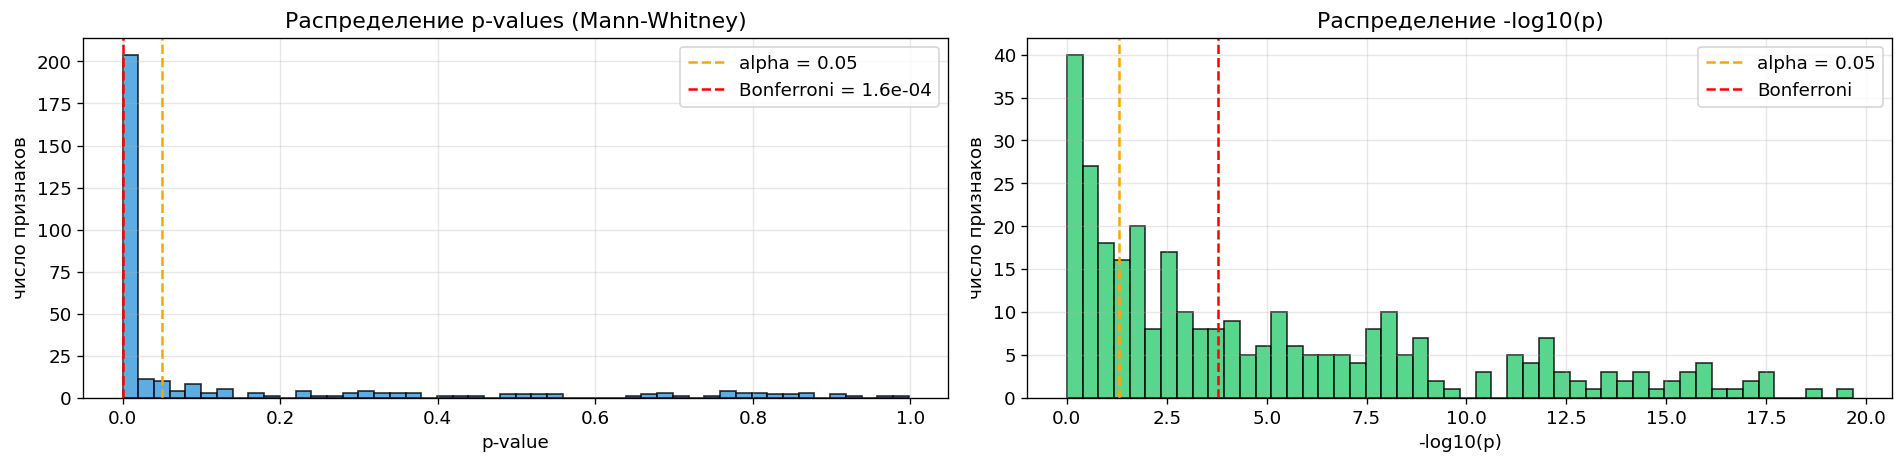

Число значимых признаков (Bonferroni) по типу агрегата:
aggregate
mean_vel_norm    24
std_vel_norm     24
std_acc_norm     22
std_norm         18
std_angle        13
max_vel_norm     12
range_angle      10
max_acc_norm      6
min_norm          6
mean_angle        5
max_norm          1
dtype: int64


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
axes[0].hist(mw_df['p_value'], bins=50, color='#3498db', alpha=0.8, edgecolor='black')
axes[0].axvline(alpha, color='orange', ls='--', label=f'alpha = {alpha}')
axes[0].axvline(alpha_bonf, color='red', ls='--', label=f'Bonferroni = {alpha_bonf:.1e}')
axes[0].set_xlabel('p-value'); axes[0].set_ylabel('число признаков')
axes[0].set_title('Распределение p-values (Mann-Whitney)')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].hist(mw_df['neg_log10_p'], bins=50, color='#2ecc71', alpha=0.8, edgecolor='black')
axes[1].axvline(-np.log10(alpha), color='orange', ls='--', label=f'alpha = {alpha}')
axes[1].axvline(-np.log10(alpha_bonf), color='red', ls='--', label='Bonferroni')
axes[1].set_xlabel('-log10(p)'); axes[1].set_ylabel('число признаков')
axes[1].set_title('Распределение -log10(p)')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

agg_sig = mw_df[mw_df['significant_bonf']].groupby('aggregate').size().sort_values(ascending=False)
print('Число значимых признаков (Bonferroni) по типу агрегата:')
print(agg_sig)


## 3. Функции пайплайна

- `prepare_data(agg_list, include_duration)` — pivot long → wide для dist_-агрегатов
- `prepare_area_data(area_agg_list, include_duration)` — выборка area_-признаков из wide-датасета
- `run_models_xy(X, y, groups)` — CV по 5 моделям, возвращает словарь метрик
- `run_models(agg_list)` / `run_area_models(area_agg_list)` — обёртки с подготовкой данных


In [11]:
class CorrelationFilter(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.95):
        self.threshold = threshold
    def fit(self, X, y=None):
        X_df = X if isinstance(X, pd.DataFrame) else pd.DataFrame(X)
        corr = X_df.corr().abs()
        upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        cols = list(upper.columns)
        to_drop = set(c for c in cols if any(upper[c] > self.threshold))
        self.keep_mask_ = np.array([c not in to_drop for c in cols])
        return self
    def transform(self, X):
        X_arr = X.values if isinstance(X, pd.DataFrame) else X
        return X_arr[:, self.keep_mask_]


def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp)

scoring = {
    'balanced_accuracy': 'balanced_accuracy',
    'accuracy':          'accuracy',
    'f1':                'f1',
    'roc_auc':           'roc_auc',
    'sensitivity':       'recall',
    'specificity':       make_scorer(specificity_score),
}


def prepare_data(agg_list, include_duration=False):
    if len(agg_list) == 1:
        sub = df[df['Aggregate'] == agg_list[0]].copy()
        feat = list(dist_cols)
        if include_duration:
            feat = feat + [DURATION_COL]
        return sub[feat], sub['label'], sub['Patient']
    sub = df[df['Aggregate'].isin(agg_list)]
    pivot = sub.pivot_table(index=['Patient','r','label'], columns='Aggregate', values=dist_cols)
    pivot.columns = [f'{f}_{a}' for f, a in pivot.columns]
    pivot = pivot.reset_index()
    feat = [c for c in pivot.columns if c.startswith('dist_')]
    if include_duration:
        dur = df.groupby(['Patient','r'])[DURATION_COL].first().reset_index()
        pivot = pivot.merge(dur, on=['Patient','r'], how='left')
        feat = feat + [DURATION_COL]
    return pivot[feat], pivot['label'], pivot['Patient']


def get_area_feat(area_agg_list):
    return [c for c in area_cols if any(c.endswith('_'+s) for s in area_agg_list)]


def prepare_area_data(area_agg_list, include_duration=False):
    feat = get_area_feat(area_agg_list)
    cols_need = ['id','r','label'] + ([DURATION_COL] if include_duration else []) + feat
    sub = df_wide[cols_need].rename(columns={'id':'Patient'})
    X = sub[feat + ([DURATION_COL] if include_duration else [])]
    return X, sub['label'], sub['Patient']


def _make_models(y):
    return {
        'LR':   LogisticRegression(max_iter=5000, class_weight='balanced', random_state=RANDOM_STATE),
        'RF':   RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                       random_state=RANDOM_STATE, n_jobs=-1),
        'XGB':  XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.1,
                              scale_pos_weight=(y==0).sum()/(y==1).sum(),
                              random_state=RANDOM_STATE, eval_metric='logloss'),
        'LGBM': LGBMClassifier(n_estimators=300, max_depth=4, learning_rate=0.1,
                               class_weight='balanced', random_state=RANDOM_STATE, verbose=-1),
        'SVM':  SVC(kernel='rbf', class_weight='balanced', probability=True,
                    random_state=RANDOM_STATE),
    }


def run_models_xy(X, y, groups):
    cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    models_dict = _make_models(y)
    res = {}
    n_feat_after = None
    for name, model in models_dict.items():
        pipe = Pipeline([
            ('corr',   CorrelationFilter(threshold=0.95)),
            ('scaler', StandardScaler()),
            ('model',  model),
        ])
        cvr = cross_validate(pipe, X, y, groups=groups, cv=cv,
                             scoring=scoring, return_train_score=False,
                             return_estimator=(name == 'LR'))
        if name == 'LR' and n_feat_after is None:
            n_feat_after = int(cvr['estimator'][0].named_steps['corr'].keep_mask_.sum())
        res[name] = {
            'bal_acc':     np.mean(cvr['test_balanced_accuracy']),
            'acc':         np.mean(cvr['test_accuracy']),
            'f1':          np.mean(cvr['test_f1']),
            'roc_auc':     np.mean(cvr['test_roc_auc']),
            'sens':        np.mean(cvr['test_sensitivity']),
            'spec':        np.mean(cvr['test_specificity']),
            'roc_auc_std': np.std(cvr['test_roc_auc']),
            'bal_acc_std': np.std(cvr['test_balanced_accuracy']),
        }
    return res, n_feat_after


def run_models(agg_list, include_duration=False):
    X, y, groups = prepare_data(agg_list, include_duration)
    return run_models_xy(X, y, groups)


def run_area_models(area_agg_list, include_duration=False):
    X, y, groups = prepare_area_data(area_agg_list, include_duration)
    return run_models_xy(X, y, groups)


print('Функции определены.')


Функции определены.


## 4. Проверка CV-схемы

In [13]:
X_cv, y_cv, groups_cv = prepare_data(GEOM_AGGS)
cv_check = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print(f'X: {X_cv.shape},  уникальных пациентов: {groups_cv.nunique()}')
for fold, (tr, te) in enumerate(cv_check.split(X_cv, y_cv, groups_cv)):
    tr_pat = set(groups_cv.iloc[tr])
    te_pat = set(groups_cv.iloc[te])
    print(f'  Fold {fold+1}: train={len(tr_pat)} пац., test={len(te_pat)} пац., '
          f'PD_test={y_cv.iloc[te].sum()}, overlap={len(tr_pat & te_pat)}')


X: (257, 120),  уникальных пациентов: 151
  Fold 1: train=121 пац., test=30 пац., PD_test=32, overlap=0
  Fold 2: train=120 пац., test=31 пац., PD_test=34, overlap=0
  Fold 3: train=122 пац., test=29 пац., PD_test=31, overlap=0
  Fold 4: train=121 пац., test=30 пац., PD_test=31, overlap=0
  Fold 5: train=120 пац., test=31 пац., PD_test=30, overlap=0


---

# Block 2. Исследование по группам агрегатов

Для каждой группы: одиночные агрегаты (таблица + heatmap) → все комбинации (рейтинг + barplot) → лучшая комбинация.


## 5. Геометрические агрегаты

Пять статистик положения ориентира: min, max, mean, median, std — нормированных на межзрачковое расстояние.
Каждый агрегат описывает форму движения с разных сторон: центральная тенденция, разброс, экстремумы.

### 5.1 Одиночные агрегаты


In [16]:
geom_aggs = GEOM_AGGS
geom_single = {}
for agg in geom_aggs:
    print(f'>>> {agg}')
    res, n_feat = run_models([agg])
    geom_single[agg] = {'res': res, 'n_feat': n_feat}
print('Готово.')


>>> min_norm
>>> max_norm
>>> mean_norm
>>> median_norm
>>> std_norm
Готово.


In [17]:
rows = []
for agg in geom_aggs:
    r = geom_single[agg]
    best_model = max(r['res'], key=lambda m: r['res'][m]['roc_auc'])
    best = r['res'][best_model]
    rows.append({'Aggregate': agg, 'Features': r['n_feat'], 'Best model': best_model,
                 'Bal.Acc': best['bal_acc'], 'ROC-AUC': best['roc_auc'],
                 'Sens': best['sens'], 'Spec': best['spec']})
geom_single_df = pd.DataFrame(rows).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
display(geom_single_df.style.format({'Bal.Acc':'{:.3f}','ROC-AUC':'{:.3f}','Sens':'{:.3f}','Spec':'{:.3f}'}))


,Aggregate,Features,Best model,Bal.Acc,ROC-AUC,Sens,Spec
0,std_norm,13,RF,0.632,0.739,0.819,0.445
1,min_norm,14,SVM,0.644,0.701,0.637,0.652
2,max_norm,13,SVM,0.601,0.639,0.609,0.593
3,mean_norm,15,LGBM,0.546,0.581,0.696,0.397
4,median_norm,15,LR,0.512,0.527,0.543,0.480


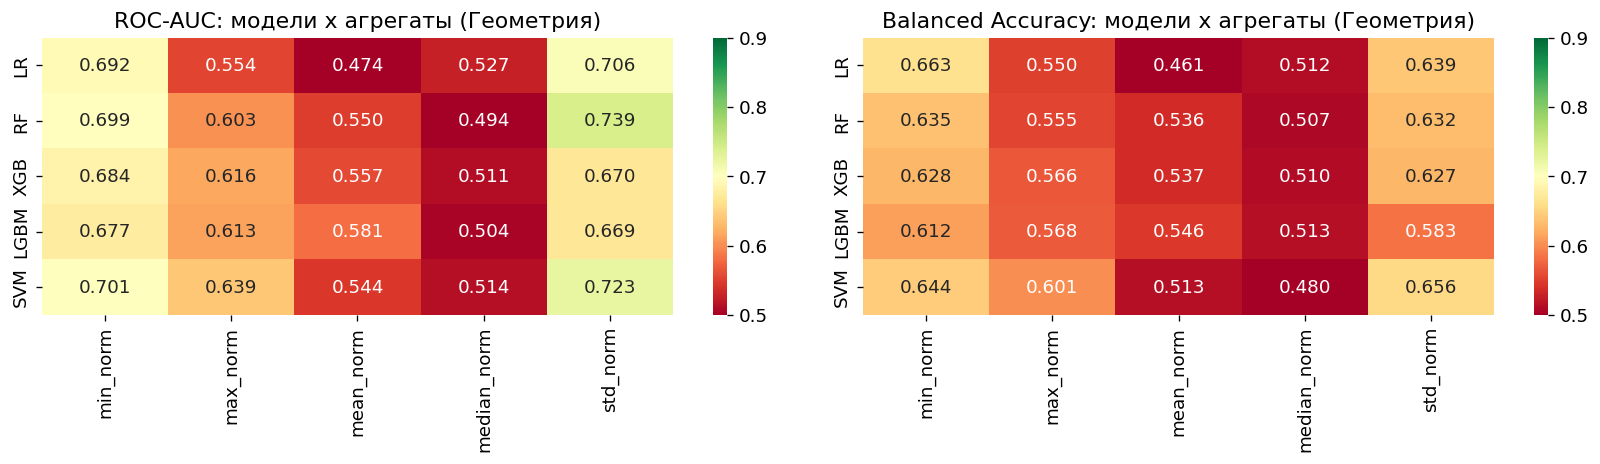

In [18]:
hm_auc = np.zeros((len(model_names), len(geom_aggs)))
hm_bal = np.zeros((len(model_names), len(geom_aggs)))
for i, mn in enumerate(model_names):
    for j, agg in enumerate(geom_aggs):
        hm_auc[i, j] = geom_single[agg]['res'][mn]['roc_auc']
        hm_bal[i, j] = geom_single[agg]['res'][mn]['bal_acc']
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.heatmap(hm_auc, xticklabels=geom_aggs, yticklabels=model_names,
            annot=True, fmt='.3f', cmap='RdYlGn', vmin=0.5, vmax=0.9, ax=axes[0])
axes[0].set_title('ROC-AUC: модели x агрегаты (Геометрия)')
sns.heatmap(hm_bal, xticklabels=geom_aggs, yticklabels=model_names,
            annot=True, fmt='.3f', cmap='RdYlGn', vmin=0.5, vmax=0.9, ax=axes[1])
axes[1].set_title('Balanced Accuracy: модели x агрегаты (Геометрия)')
plt.tight_layout(); plt.show()


### 5.2 Все комбинации агрегатов

In [20]:
geom_combos = dict(geom_single)
for n_c in range(2, len(geom_aggs) + 1):
    for combo in combinations(geom_aggs, n_c):
        combo_name = '+'.join(combo)
        print(f'>>> {combo_name}')
        res, n_feat = run_models(list(combo))
        geom_combos[combo_name] = {'res': res, 'n_feat': n_feat}
print(f'Всего комбинаций: {len(geom_combos)}')


>>> min_norm+max_norm
>>> min_norm+mean_norm
>>> min_norm+median_norm
>>> min_norm+std_norm
>>> max_norm+mean_norm
>>> max_norm+median_norm
>>> max_norm+std_norm
>>> mean_norm+median_norm
>>> mean_norm+std_norm
>>> median_norm+std_norm
>>> min_norm+max_norm+mean_norm
>>> min_norm+max_norm+median_norm
>>> min_norm+max_norm+std_norm
>>> min_norm+mean_norm+median_norm
>>> min_norm+mean_norm+std_norm
>>> min_norm+median_norm+std_norm
>>> max_norm+mean_norm+median_norm
>>> max_norm+mean_norm+std_norm
>>> max_norm+median_norm+std_norm
>>> mean_norm+median_norm+std_norm
>>> min_norm+max_norm+mean_norm+median_norm
>>> min_norm+max_norm+mean_norm+std_norm
>>> min_norm+max_norm+median_norm+std_norm
>>> min_norm+mean_norm+median_norm+std_norm
>>> max_norm+mean_norm+median_norm+std_norm
>>> min_norm+max_norm+mean_norm+median_norm+std_norm
Всего комбинаций: 31


,Aggregates,N_agg,Features,Best model,Bal.Acc,F1,ROC-AUC,Sens,Spec
0,min_norm+max_norm+median_norm+std_norm,4,55,LGBM,0.684,0.749,0.790,0.749,0.619
1,min_norm+max_norm+mean_norm+median_norm+std_norm,5,55,LGBM,0.661,0.741,0.778,0.756,0.566
2,min_norm+max_norm+mean_norm+std_norm,4,55,LGBM,0.661,0.741,0.778,0.756,0.566
3,max_norm+median_norm+std_norm,3,41,XGB,0.685,0.748,0.774,0.767,0.603
4,min_norm+median_norm+std_norm,3,42,XGB,0.689,0.755,0.771,0.756,0.622
5,min_norm+max_norm+std_norm,3,40,LGBM,0.678,0.751,0.769,0.763,0.593
6,min_norm+mean_norm+median_norm+std_norm,4,42,RF,0.656,0.758,0.763,0.813,0.498
7,min_norm+mean_norm+std_norm,3,42,RF,0.656,0.758,0.763,0.813,0.498
8,min_norm+max_norm+median_norm,3,42,LGBM,0.663,0.745,0.762,0.740,0.586
9,max_norm+mean_norm+std_norm,3,41,LGBM,0.675,0.741,0.760,0.750,0.600


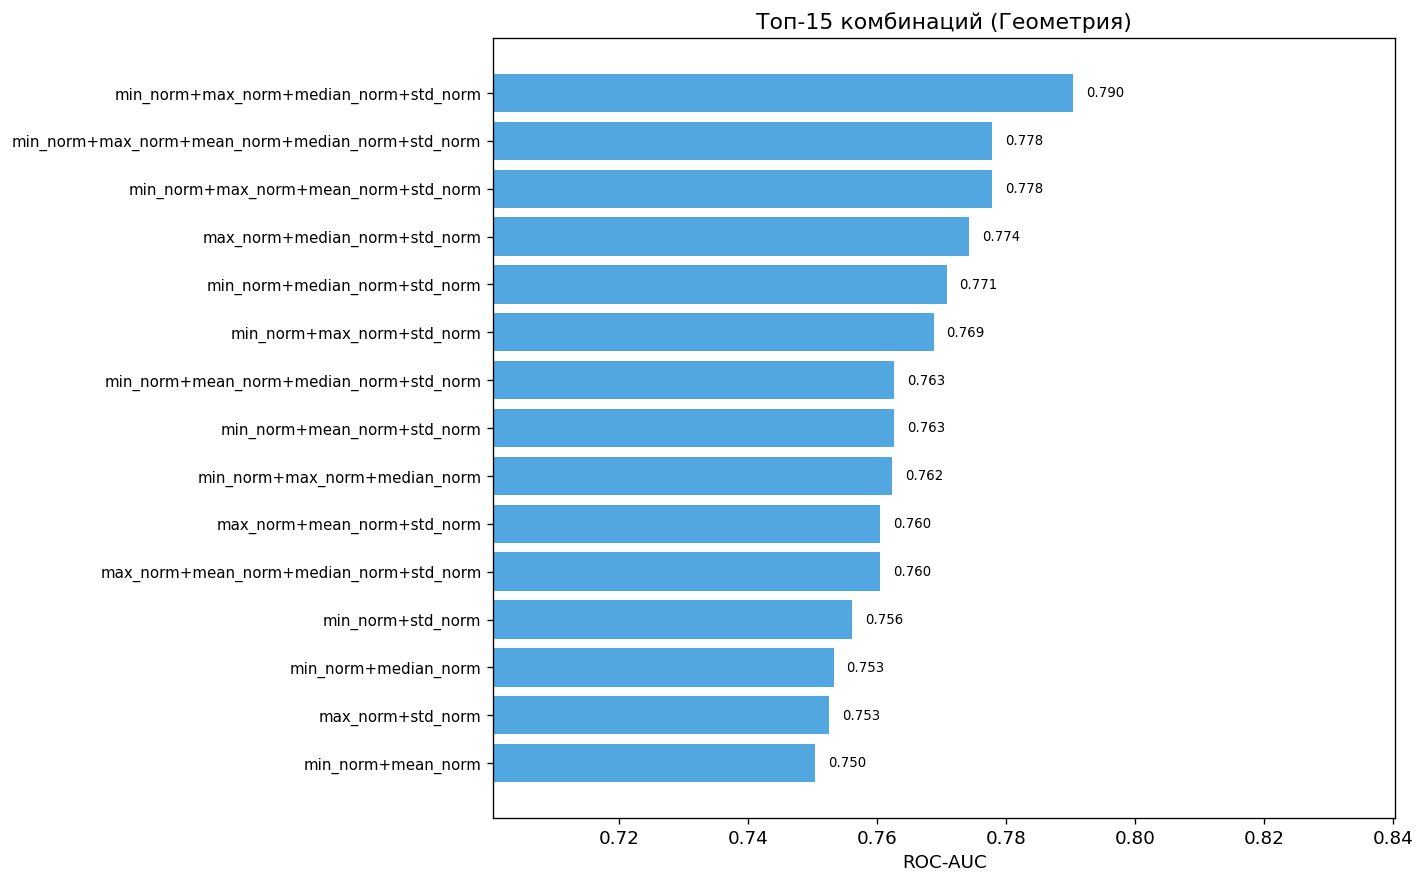

Лучшая комбинация (Геометрия): min_norm+max_norm+median_norm+std_norm


In [21]:
combo_rows_geom = []
for combo_name, data in geom_combos.items():
    best_model = max(data['res'], key=lambda m: data['res'][m]['roc_auc'])
    best = data['res'][best_model]
    combo_rows_geom.append({'Aggregates': combo_name, 'N_agg': combo_name.count('+')+1,
                            'Features': data['n_feat'], 'Best model': best_model,
                            'Bal.Acc': best['bal_acc'], 'F1': best['f1'],
                            'ROC-AUC': best['roc_auc'], 'Sens': best['sens'], 'Spec': best['spec']})
geom_combo_df = pd.DataFrame(combo_rows_geom).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
display(geom_combo_df.style.format({'Bal.Acc':'{:.3f}','F1':'{:.3f}','ROC-AUC':'{:.3f}','Sens':'{:.3f}','Spec':'{:.3f}'}))

top_n = min(15, len(geom_combo_df))
top = geom_combo_df.head(top_n)
fig, ax = plt.subplots(figsize=(12, max(5, top_n*0.5)))
ax.barh(range(len(top)), top['ROC-AUC'].values, color='#3498db', alpha=0.85)
ax.set_yticks(range(len(top))); ax.set_yticklabels(top['Aggregates'].values, fontsize=13)
ax.set_xlabel('ROC-AUC'); ax.set_title(f'Топ-{top_n} комбинаций (Геометрия)')
ax.invert_yaxis()
ax.set_xlim(max(0.4, top['ROC-AUC'].min()-0.05), min(1.0, top['ROC-AUC'].max()+0.05))
for i, val in enumerate(top['ROC-AUC'].values): ax.text(val+0.002, i, f'{val:.3f}', va='center', fontsize=13)
plt.tight_layout(); plt.show()

geom_best_name = geom_combo_df.iloc[0]['Aggregates']
geom_best_list = geom_best_name.split('+')
print(f'Лучшая комбинация (Геометрия): {geom_best_name}')


## 6. Динамические агрегаты (скорость + ускорение)

Пять агрегатов динамики: max_vel_norm, mean_vel_norm, std_vel_norm (скорость), max_acc_norm, std_acc_norm (ускорение).
Описывают темп и характер движения при поднятии бровей. Брадикинезия при ПД проявляется в замедлении моторных актов.

### 6.1 Одиночные агрегаты


In [23]:
dyn_aggs = DYN_AGGS
dyn_single = {}
for agg in dyn_aggs:
    print(f'>>> {agg}')
    res, n_feat = run_models([agg])
    dyn_single[agg] = {'res': res, 'n_feat': n_feat}
print('Готово.')


>>> max_vel_norm
>>> mean_vel_norm
>>> std_vel_norm
>>> max_acc_norm
>>> std_acc_norm
Готово.


,Aggregate,Features,Best model,Bal.Acc,ROC-AUC,Sens,Spec
0,max_vel_norm,13,XGB,0.710,0.816,0.783,0.637
1,mean_vel_norm,11,SVM,0.735,0.809,0.752,0.718
2,std_vel_norm,12,SVM,0.728,0.795,0.726,0.730
3,std_acc_norm,10,SVM,0.697,0.753,0.664,0.729
4,max_acc_norm,13,RF,0.635,0.730,0.790,0.480


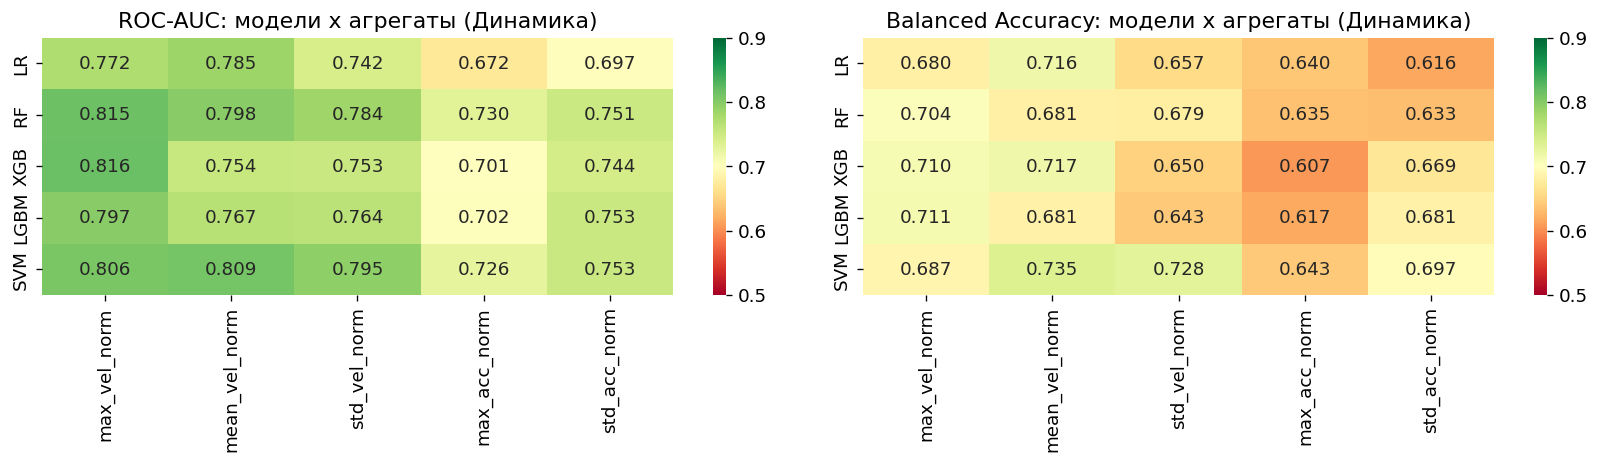

In [24]:
rows = []
for agg in dyn_aggs:
    r = dyn_single[agg]
    best_model = max(r['res'], key=lambda m: r['res'][m]['roc_auc'])
    best = r['res'][best_model]
    rows.append({'Aggregate': agg, 'Features': r['n_feat'], 'Best model': best_model,
                 'Bal.Acc': best['bal_acc'], 'ROC-AUC': best['roc_auc'],
                 'Sens': best['sens'], 'Spec': best['spec']})
dyn_single_df = pd.DataFrame(rows).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
display(dyn_single_df.style.format({'Bal.Acc':'{:.3f}','ROC-AUC':'{:.3f}','Sens':'{:.3f}','Spec':'{:.3f}'}))

hm_auc = np.zeros((len(model_names), len(dyn_aggs)))
hm_bal = np.zeros((len(model_names), len(dyn_aggs)))
for i, mn in enumerate(model_names):
    for j, agg in enumerate(dyn_aggs):
        hm_auc[i,j] = dyn_single[agg]['res'][mn]['roc_auc']
        hm_bal[i,j] = dyn_single[agg]['res'][mn]['bal_acc']
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.heatmap(hm_auc, xticklabels=dyn_aggs, yticklabels=model_names,
            annot=True, fmt='.3f', cmap='RdYlGn', vmin=0.5, vmax=0.9, ax=axes[0])
axes[0].set_title('ROC-AUC: модели x агрегаты (Динамика)')
sns.heatmap(hm_bal, xticklabels=dyn_aggs, yticklabels=model_names,
            annot=True, fmt='.3f', cmap='RdYlGn', vmin=0.5, vmax=0.9, ax=axes[1])
axes[1].set_title('Balanced Accuracy: модели x агрегаты (Динамика)')
plt.tight_layout(); plt.show()


### 6.2 Все комбинации агрегатов

>>> max_vel_norm+mean_vel_norm
>>> max_vel_norm+std_vel_norm
>>> max_vel_norm+max_acc_norm
>>> max_vel_norm+std_acc_norm
>>> mean_vel_norm+std_vel_norm
>>> mean_vel_norm+max_acc_norm
>>> mean_vel_norm+std_acc_norm
>>> std_vel_norm+max_acc_norm
>>> std_vel_norm+std_acc_norm
>>> max_acc_norm+std_acc_norm
>>> max_vel_norm+mean_vel_norm+std_vel_norm
>>> max_vel_norm+mean_vel_norm+max_acc_norm
>>> max_vel_norm+mean_vel_norm+std_acc_norm
>>> max_vel_norm+std_vel_norm+max_acc_norm
>>> max_vel_norm+std_vel_norm+std_acc_norm
>>> max_vel_norm+max_acc_norm+std_acc_norm
>>> mean_vel_norm+std_vel_norm+max_acc_norm
>>> mean_vel_norm+std_vel_norm+std_acc_norm
>>> mean_vel_norm+max_acc_norm+std_acc_norm
>>> std_vel_norm+max_acc_norm+std_acc_norm
>>> max_vel_norm+mean_vel_norm+std_vel_norm+max_acc_norm
>>> max_vel_norm+mean_vel_norm+std_vel_norm+std_acc_norm
>>> max_vel_norm+mean_vel_norm+max_acc_norm+std_acc_norm
>>> max_vel_norm+std_vel_norm+max_acc_norm+std_acc_norm
>>> mean_vel_norm+std_vel_norm+ma

,Aggregates,N_agg,Features,Best model,Bal.Acc,F1,ROC-AUC,Sens,Spec
0,max_vel_norm+mean_vel_norm+std_vel_norm+max_acc_norm+std_acc_norm,5,47,XGB,0.770,0.828,0.898,0.835,0.705
1,max_vel_norm+mean_vel_norm+std_vel_norm+std_acc_norm,4,34,LR,0.794,0.843,0.897,0.841,0.747
2,max_vel_norm+mean_vel_norm+std_acc_norm,3,34,LR,0.794,0.843,0.897,0.841,0.747
3,max_vel_norm+mean_vel_norm+max_acc_norm+std_acc_norm,4,47,XGB,0.766,0.826,0.896,0.835,0.696
4,max_vel_norm+mean_vel_norm,2,24,XGB,0.773,0.821,0.890,0.804,0.742
5,max_vel_norm+mean_vel_norm+max_acc_norm,3,37,XGB,0.783,0.828,0.889,0.816,0.751
6,max_vel_norm+mean_vel_norm+std_vel_norm+max_acc_norm,4,41,XGB,0.783,0.828,0.888,0.816,0.749
7,max_vel_norm+mean_vel_norm+std_vel_norm,3,28,XGB,0.765,0.816,0.887,0.804,0.727
8,max_vel_norm+std_vel_norm+max_acc_norm+std_acc_norm,4,43,XGB,0.751,0.797,0.885,0.802,0.699
9,max_vel_norm+std_vel_norm+std_acc_norm,3,30,XGB,0.774,0.816,0.883,0.814,0.734


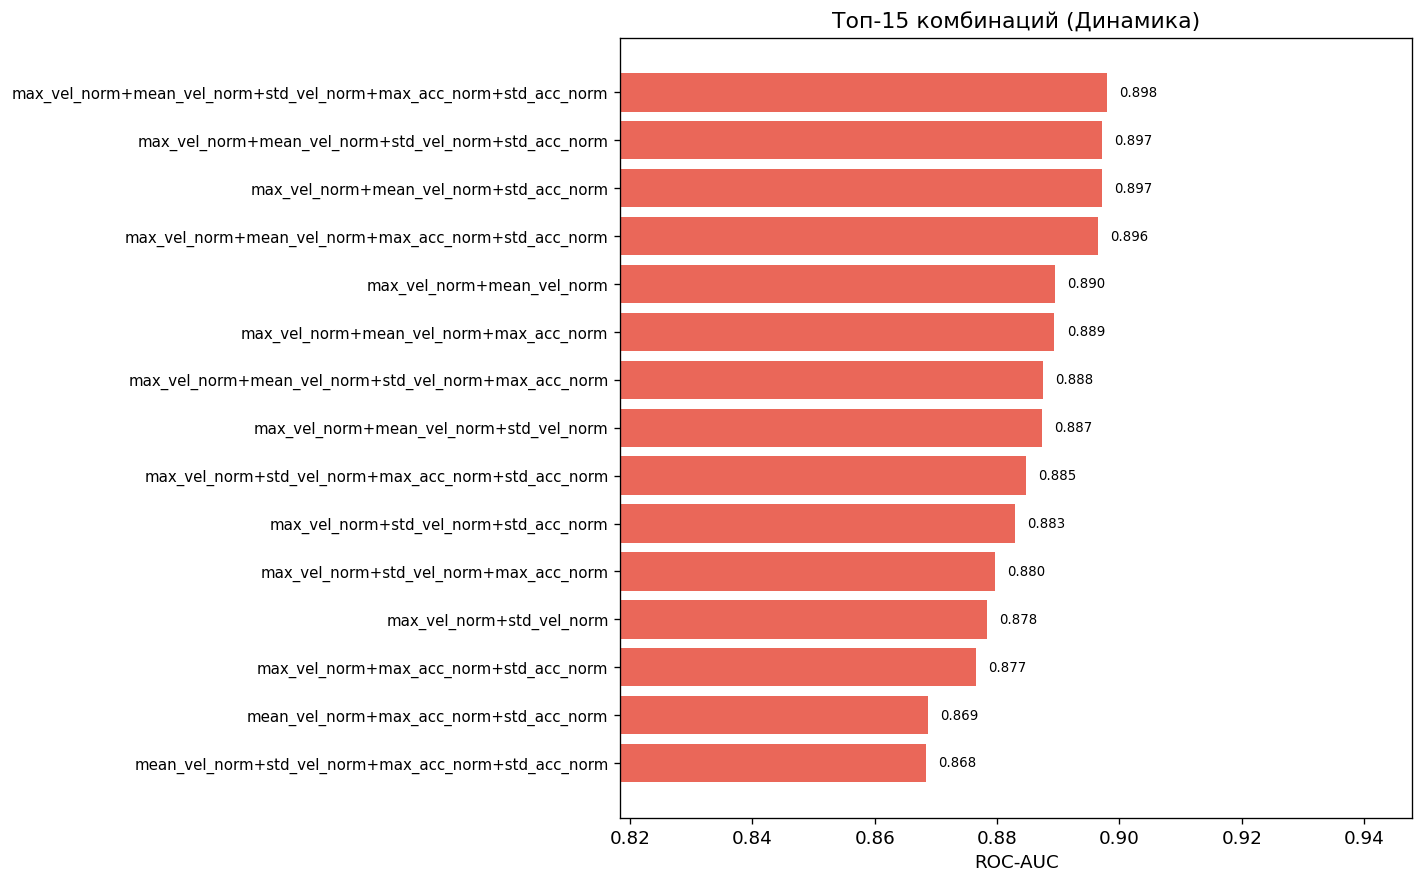

Лучшая комбинация (Динамика): max_vel_norm+mean_vel_norm+std_vel_norm+max_acc_norm+std_acc_norm


In [26]:
dyn_combos = dict(dyn_single)
for n_c in range(2, len(dyn_aggs) + 1):
    for combo in combinations(dyn_aggs, n_c):
        combo_name = '+'.join(combo)
        print(f'>>> {combo_name}')
        res, n_feat = run_models(list(combo))
        dyn_combos[combo_name] = {'res': res, 'n_feat': n_feat}
print(f'Всего комбинаций: {len(dyn_combos)}')

combo_rows_dyn = []
for combo_name, data in dyn_combos.items():
    best_model = max(data['res'], key=lambda m: data['res'][m]['roc_auc'])
    best = data['res'][best_model]
    combo_rows_dyn.append({'Aggregates': combo_name, 'N_agg': combo_name.count('+')+1,
                           'Features': data['n_feat'], 'Best model': best_model,
                           'Bal.Acc': best['bal_acc'], 'F1': best['f1'],
                           'ROC-AUC': best['roc_auc'], 'Sens': best['sens'], 'Spec': best['spec']})
dyn_combo_df = pd.DataFrame(combo_rows_dyn).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
display(dyn_combo_df.style.format({'Bal.Acc':'{:.3f}','F1':'{:.3f}','ROC-AUC':'{:.3f}','Sens':'{:.3f}','Spec':'{:.3f}'}))

top_n = min(15, len(dyn_combo_df))
top = dyn_combo_df.head(top_n)
fig, ax = plt.subplots(figsize=(12, max(5, top_n*0.5)))
ax.barh(range(len(top)), top['ROC-AUC'].values, color='#e74c3c', alpha=0.85)
ax.set_yticks(range(len(top))); ax.set_yticklabels(top['Aggregates'].values, fontsize=13)
ax.set_xlabel('ROC-AUC'); ax.set_title(f'Топ-{top_n} комбинаций (Динамика)')
ax.invert_yaxis()
ax.set_xlim(max(0.4, top['ROC-AUC'].min()-0.05), min(1.0, top['ROC-AUC'].max()+0.05))
for i, val in enumerate(top['ROC-AUC'].values): ax.text(val+0.002, i, f'{val:.3f}', va='center', fontsize=13)
plt.tight_layout(); plt.show()

dyn_best_name = dyn_combo_df.iloc[0]['Aggregates']
dyn_best_list = dyn_best_name.split('+')
print(f'Лучшая комбинация (Динамика): {dyn_best_name}')


## 7. Угловые агрегаты

Три агрегата углов между последовательными векторами движения: mean_angle, std_angle, range_angle.
Отражают плавность и направленность движения при поднятии бровей.

### 7.1 Одиночные агрегаты


In [28]:
ang_aggs = ANG_AGGS
ang_single = {}
for agg in ang_aggs:
    print(f'>>> {agg}')
    res, n_feat = run_models([agg])
    ang_single[agg] = {'res': res, 'n_feat': n_feat}
print('Готово.')

rows = []
for agg in ang_aggs:
    r = ang_single[agg]
    best_model = max(r['res'], key=lambda m: r['res'][m]['roc_auc'])
    best = r['res'][best_model]
    rows.append({'Aggregate': agg, 'Features': r['n_feat'], 'Best model': best_model,
                 'Bal.Acc': best['bal_acc'], 'ROC-AUC': best['roc_auc'],
                 'Sens': best['sens'], 'Spec': best['spec']})
ang_single_df = pd.DataFrame(rows).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
display(ang_single_df.style.format({'Bal.Acc':'{:.3f}','ROC-AUC':'{:.3f}','Sens':'{:.3f}','Spec':'{:.3f}'}))


>>> mean_angle
>>> std_angle
>>> range_angle
Готово.


,Aggregate,Features,Best model,Bal.Acc,ROC-AUC,Sens,Spec
0,range_angle,16,SVM,0.734,0.798,0.676,0.792
1,std_angle,17,SVM,0.668,0.780,0.650,0.685
2,mean_angle,12,LGBM,0.618,0.699,0.757,0.479


In [29]:
ang_combos = dict(ang_single)
for n_c in range(2, len(ang_aggs) + 1):
    for combo in combinations(ang_aggs, n_c):
        combo_name = '+'.join(combo)
        print(f'>>> {combo_name}')
        res, n_feat = run_models(list(combo))
        ang_combos[combo_name] = {'res': res, 'n_feat': n_feat}
print(f'Всего комбинаций: {len(ang_combos)}')

combo_rows_ang = []
for combo_name, data in ang_combos.items():
    best_model = max(data['res'], key=lambda m: data['res'][m]['roc_auc'])
    best = data['res'][best_model]
    combo_rows_ang.append({'Aggregates': combo_name, 'N_agg': combo_name.count('+')+1,
                           'Features': data['n_feat'], 'Best model': best_model,
                           'Bal.Acc': best['bal_acc'], 'F1': best['f1'],
                           'ROC-AUC': best['roc_auc'], 'Sens': best['sens'], 'Spec': best['spec']})
ang_combo_df = pd.DataFrame(combo_rows_ang).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
display(ang_combo_df.style.format({'Bal.Acc':'{:.3f}','F1':'{:.3f}','ROC-AUC':'{:.3f}','Sens':'{:.3f}','Spec':'{:.3f}'}))

ang_best_name = ang_combo_df.iloc[0]['Aggregates']
ang_best_list = ang_best_name.split('+')
print(f'Лучшая комбинация (Углы): {ang_best_name}')


>>> mean_angle+std_angle
>>> mean_angle+range_angle
>>> std_angle+range_angle
>>> mean_angle+std_angle+range_angle
Всего комбинаций: 7


,Aggregates,N_agg,Features,Best model,Bal.Acc,F1,ROC-AUC,Sens,Spec
0,mean_angle+range_angle,2,28,RF,0.658,0.790,0.826,0.873,0.444
1,mean_angle+std_angle+range_angle,3,44,RF,0.674,0.807,0.824,0.898,0.449
2,std_angle+range_angle,2,32,SVM,0.708,0.742,0.806,0.702,0.715
3,range_angle,1,16,SVM,0.734,0.736,0.798,0.676,0.792
4,mean_angle+std_angle,2,29,SVM,0.689,0.732,0.793,0.713,0.665
5,std_angle,1,17,SVM,0.668,0.690,0.780,0.650,0.685
6,mean_angle,1,12,LGBM,0.618,0.721,0.699,0.757,0.479


Лучшая комбинация (Углы): mean_angle+range_angle


## 8. Площадные признаки

165 треугольников из 3 групп landmarks поднятия бровей × 6 агрегатов (min/max/mean/median/std/range площади).
Площади нормированы на квадрат межзрачкового расстояния. Источник: wide-датасет.

### 8.0 Схема треугольников на лице


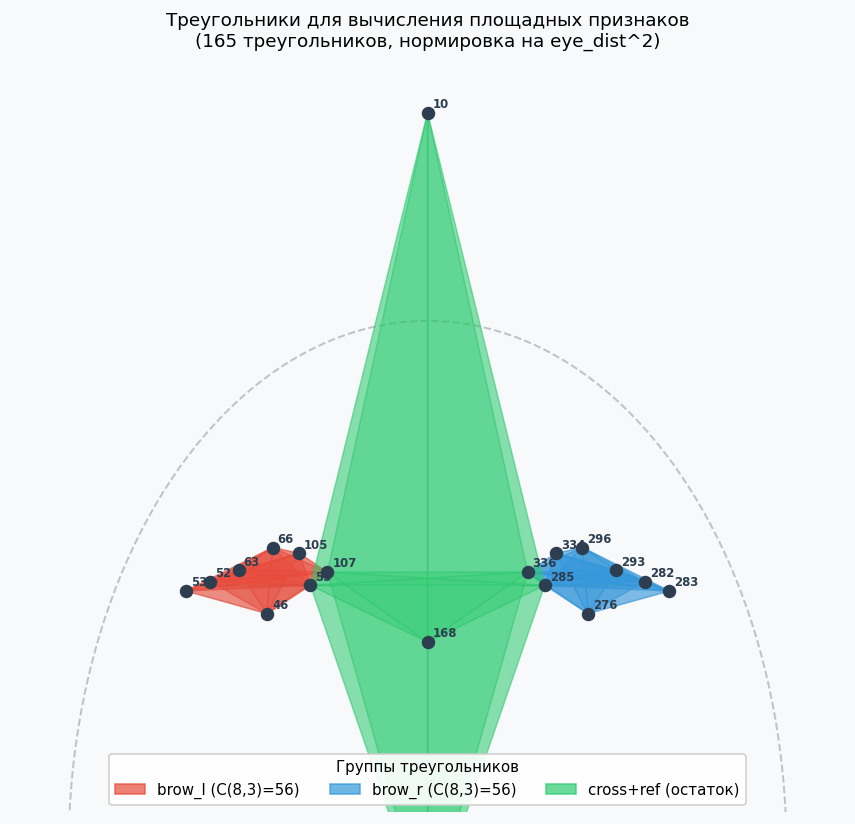

Агрегаты площадей: ['area_min', 'area_max', 'area_mean', 'area_median', 'area_std', 'area_range']
Всего area_ признаков: 990  (165 * 6 = 990)


In [31]:
# Аппроксимированные 2D-координаты MediaPipe landmarks (нормировано 0-1, y: 0=верх)
# Брови и опорные точки (поднятие бровей)
COORDS_VIS = {
    # Левая бровь (brow_l)
    46:  (0.415, 0.375),
    52:  (0.385, 0.358),
    53:  (0.372, 0.363),
    55:  (0.438, 0.360),
    63:  (0.400, 0.352),
    66:  (0.418, 0.340),
    105: (0.432, 0.343),
    107: (0.447, 0.353),
    # Правая бровь (brow_r, зеркально)
    276: (0.585, 0.375),
    282: (0.615, 0.358),
    283: (0.628, 0.363),
    285: (0.562, 0.360),
    293: (0.600, 0.352),
    296: (0.582, 0.340),
    334: (0.568, 0.343),
    336: (0.553, 0.353),
    # Опорные точки
    4:   (0.500, 0.540),   # кончик носа
    10:  (0.500, 0.110),   # лоб
    168: (0.500, 0.390),   # межбровье (глабелла)
}

GROUPS_VIS = {
    'brow_l (C(8,3)=56)':  ([46,52,53,55,63,66,105,107], '#e74c3c'),
    'brow_r (C(8,3)=56)':  ([276,282,283,285,293,296,334,336], '#3498db'),
    'cross+ref (остаток)': ([4,10,168,55,107,285,336], '#2ecc71'),
}

fig, ax = plt.subplots(figsize=(10, 7))
ax.set_facecolor('#f8f9fa')
fig.patch.set_facecolor('#f8f9fa')

for g_label, (pts_g, color) in GROUPS_VIS.items():
    pts_in_data = [p for p in pts_g if p in COORDS_VIS]
    for tri in combinations(pts_in_data, 3):
        coords = [COORDS_VIS[p] for p in tri]
        xs_t = [c[0] for c in coords]; ys_t = [1-c[1] for c in coords]
        ax.add_patch(plt.Polygon(list(zip(xs_t, ys_t)), closed=True,
                                 alpha=0.15, facecolor=color, edgecolor=color, linewidth=0.8))

for pt_id, (lx, ly) in COORDS_VIS.items():
    ax.scatter(lx, 1-ly, s=50, c='#2c3e50', zorder=5)
    ax.annotate(str(pt_id), (lx, 1-ly), textcoords='offset points',
                xytext=(3,3), fontsize=13, color='#2c3e50', fontweight='bold')

handles = [mpatches.Patch(color=c, alpha=0.7, label=g)
           for g, (_, c) in GROUPS_VIS.items()]
ax.legend(handles=handles, loc='lower center', ncol=3, fontsize=13, framealpha=0.9,
          title='Группы треугольников', title_fontsize=13)

theta = np.linspace(0, 2*np.pi, 200)
ax.plot(0.5 + 0.19*np.cos(theta), 0.5 + 0.28*np.sin(theta),
        '--', color='#bdc3c7', lw=1.2, zorder=0)
ax.plot([0.39,0.45],[0.64,0.64], '-', color='#bdc3c7', lw=1.5, zorder=0)
ax.plot([0.55,0.61],[0.64,0.64], '-', color='#bdc3c7', lw=1.5, zorder=0)

ax.set_xlim(0.28, 0.72); ax.set_ylim(0.52, 0.92)
ax.set_aspect('equal'); ax.axis('off')
ax.set_title('Треугольники для вычисления площадных признаков\n'
             f'(165 треугольников, нормировка на eye_dist^2)', fontsize=13)
plt.tight_layout(); plt.show()
print(f'Агрегаты площадей: {AREA_AGGS}')
print(f'Всего area_ признаков: {len(area_cols)}  (165 * 6 = 990)')


### 8.1 Одиночные агрегаты площадей

In [33]:
area_aggs_list = AREA_AGGS
area_single = {}
for agg in area_aggs_list:
    print(f'>>> {agg}')
    res, n_feat = run_area_models([agg])
    area_single[agg] = {'res': res, 'n_feat': n_feat}
print('Готово.')

rows = []
for agg in area_aggs_list:
    r = area_single[agg]
    best_model = max(r['res'], key=lambda m: r['res'][m]['roc_auc'])
    best = r['res'][best_model]
    rows.append({'Aggregate': agg, 'Features': r['n_feat'], 'Best model': best_model,
                 'Bal.Acc': best['bal_acc'], 'ROC-AUC': best['roc_auc'],
                 'Sens': best['sens'], 'Spec': best['spec']})
area_single_df = pd.DataFrame(rows).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
display(area_single_df.style.format({'Bal.Acc':'{:.3f}','ROC-AUC':'{:.3f}','Sens':'{:.3f}','Spec':'{:.3f}'}))


>>> area_min
>>> area_max
>>> area_mean
>>> area_median
>>> area_std
>>> area_range
Готово.


,Aggregate,Features,Best model,Bal.Acc,ROC-AUC,Sens,Spec
0,area_range,68,LR,0.708,0.798,0.760,0.655
1,area_std,70,RF,0.627,0.762,0.830,0.424
2,area_max,49,XGB,0.695,0.757,0.790,0.600
3,area_min,51,LR,0.652,0.701,0.730,0.573
4,area_mean,45,RF,0.560,0.671,0.842,0.279
5,area_median,46,RF,0.563,0.657,0.842,0.285


### 8.2 Все комбинации агрегатов

>>> area_min+area_max
>>> area_min+area_mean
>>> area_min+area_median
>>> area_min+area_std
>>> area_min+area_range
>>> area_max+area_mean
>>> area_max+area_median
>>> area_max+area_std
>>> area_max+area_range
>>> area_mean+area_median
>>> area_mean+area_std
>>> area_mean+area_range
>>> area_median+area_std
>>> area_median+area_range
>>> area_std+area_range
>>> area_min+area_max+area_mean
>>> area_min+area_max+area_median
>>> area_min+area_max+area_std
>>> area_min+area_max+area_range
>>> area_min+area_mean+area_median
>>> area_min+area_mean+area_std
>>> area_min+area_mean+area_range
>>> area_min+area_median+area_std
>>> area_min+area_median+area_range
>>> area_min+area_std+area_range
>>> area_max+area_mean+area_median
>>> area_max+area_mean+area_std
>>> area_max+area_mean+area_range
>>> area_max+area_median+area_std
>>> area_max+area_median+area_range
>>> area_max+area_std+area_range
>>> area_mean+area_median+area_std
>>> area_mean+area_median+area_range
>>> area_mean+area_std+area_ra

,Aggregates,N_agg,Features,Best model,Bal.Acc,F1,ROC-AUC,Sens,Spec
0,area_min+area_max+area_range,3,168,RF,0.707,0.811,0.817,0.881,0.533
1,area_min+area_mean+area_median+area_range,4,164,RF,0.727,0.821,0.811,0.886,0.569
2,area_min+area_mean+area_range,3,164,RF,0.727,0.821,0.811,0.886,0.569
3,area_min+area_range,2,119,RF,0.710,0.807,0.810,0.874,0.546
4,area_min+area_max+area_mean+area_range,4,213,RF,0.711,0.813,0.807,0.893,0.529
5,area_min+area_max+area_mean+area_median+area_range,5,213,RF,0.711,0.813,0.807,0.893,0.529
6,area_min+area_max+area_median+area_std,4,216,RF,0.694,0.802,0.806,0.881,0.507
7,area_max+area_range,2,117,SVM,0.741,0.785,0.806,0.778,0.705
8,area_min+area_max+area_median+area_range,4,214,RF,0.721,0.819,0.804,0.899,0.543
9,area_min+area_max+area_mean+area_median+area_std+area_range,6,283,RF,0.703,0.804,0.802,0.863,0.544


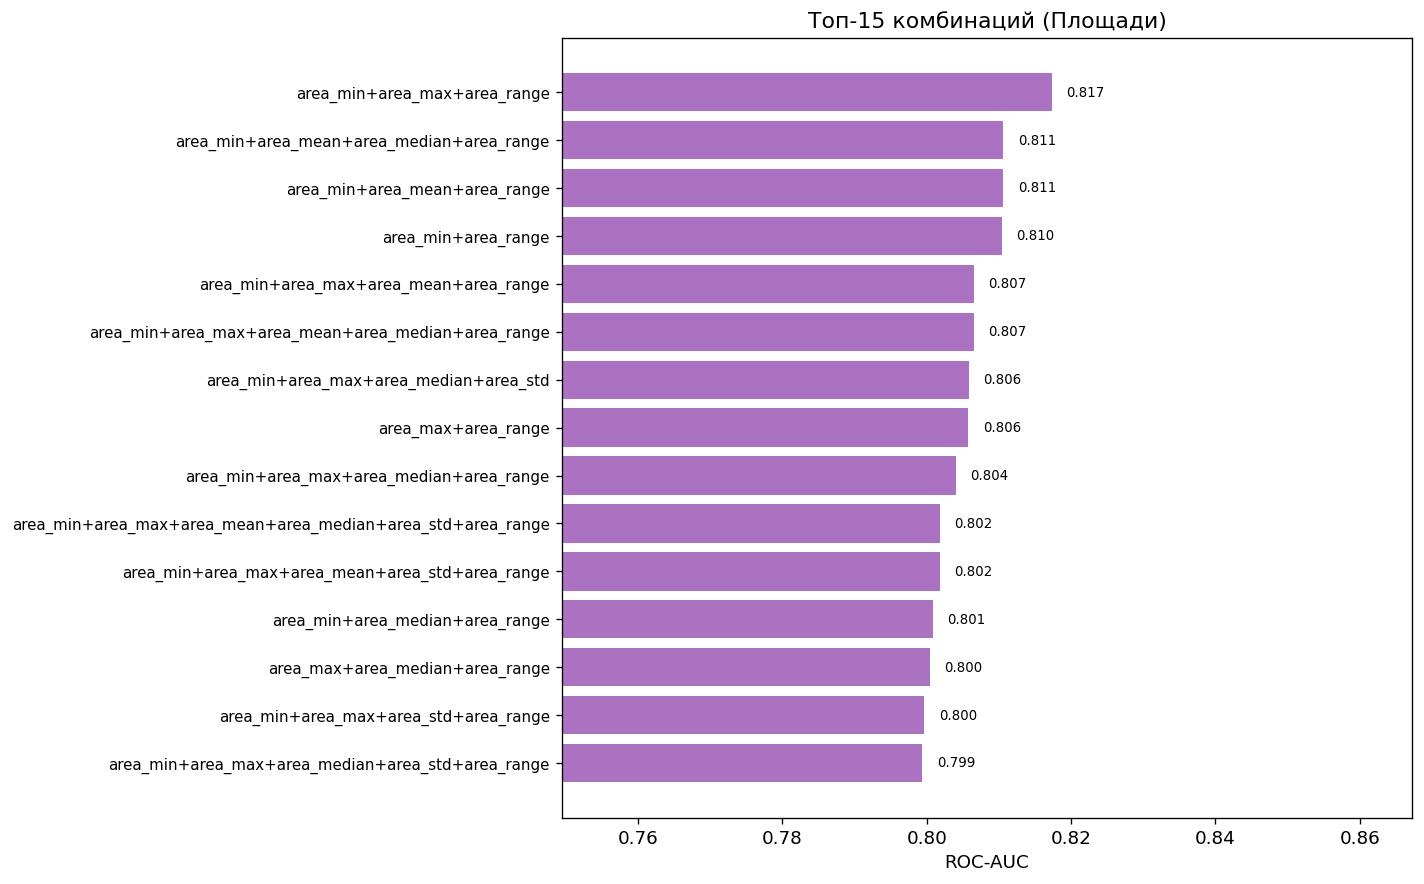

Лучшая комбинация (Площади): area_min+area_max+area_range


In [35]:
area_combos = dict(area_single)
for n_c in range(2, len(area_aggs_list) + 1):
    for combo in combinations(area_aggs_list, n_c):
        combo_name = '+'.join(combo)
        print(f'>>> {combo_name}')
        res, n_feat = run_area_models(list(combo))
        area_combos[combo_name] = {'res': res, 'n_feat': n_feat}
print(f'Всего комбинаций: {len(area_combos)}')

combo_rows_area = []
for combo_name, data in area_combos.items():
    best_model = max(data['res'], key=lambda m: data['res'][m]['roc_auc'])
    best = data['res'][best_model]
    combo_rows_area.append({'Aggregates': combo_name, 'N_agg': combo_name.count('+')+1,
                            'Features': data['n_feat'], 'Best model': best_model,
                            'Bal.Acc': best['bal_acc'], 'F1': best['f1'],
                            'ROC-AUC': best['roc_auc'], 'Sens': best['sens'], 'Spec': best['spec']})
area_combo_df = pd.DataFrame(combo_rows_area).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
display(area_combo_df.style.format({'Bal.Acc':'{:.3f}','F1':'{:.3f}','ROC-AUC':'{:.3f}','Sens':'{:.3f}','Spec':'{:.3f}'}))

top_n = min(15, len(area_combo_df))
top = area_combo_df.head(top_n)
fig, ax = plt.subplots(figsize=(12, max(5, top_n*0.5)))
ax.barh(range(len(top)), top['ROC-AUC'].values, color='#9b59b6', alpha=0.85)
ax.set_yticks(range(len(top))); ax.set_yticklabels(top['Aggregates'].values, fontsize=13)
ax.set_xlabel('ROC-AUC'); ax.set_title(f'Топ-{top_n} комбинаций (Площади)')
ax.invert_yaxis()
ax.set_xlim(max(0.4, top['ROC-AUC'].min()-0.05), min(1.0, top['ROC-AUC'].max()+0.05))
for i, val in enumerate(top['ROC-AUC'].values): ax.text(val+0.002, i, f'{val:.3f}', va='center', fontsize=13)
plt.tight_layout(); plt.show()

area_best_name = area_combo_df.iloc[0]['Aggregates']
area_best_list = area_best_name.split('+')
print(f'Лучшая комбинация (Площади): {area_best_name}')


## 9. Межгрупповое сравнение: лучшие агрегаты из каждой группы

Объединяем лучшие наборы агрегатов из каждой группы (Геометрия, Динамика, Углы, Площади).


In [37]:
def prepare_combined(dist_agg_list, area_agg_list=None, include_duration=False):
    if len(dist_agg_list) == 1:
        sub = df[df['Aggregate'] == dist_agg_list[0]].copy()
        pivot = sub[['Patient','r','label',DURATION_COL] + list(dist_cols)].copy()
        feat = list(dist_cols)
    else:
        sub = df[df['Aggregate'].isin(dist_agg_list)]
        pivot = sub.pivot_table(index=['Patient','r','label',DURATION_COL],
                                columns='Aggregate', values=dist_cols, aggfunc='first')
        pivot.columns = [f'{f}_{a}' for f, a in pivot.columns]
        pivot = pivot.reset_index()
        feat = [c for c in pivot.columns if c.startswith('dist_')]
    if area_agg_list:
        area_feat = get_area_feat(area_agg_list)
        sub_area = df_wide[['id','r'] + area_feat].rename(columns={'id': 'Patient'})
        pivot = pivot.merge(sub_area, on=['Patient','r'], how='left')
        feat = feat + area_feat
    if include_duration:
        feat = feat + [DURATION_COL]
    return pivot[feat], pivot['label'], pivot['Patient']

print('Лучшие комбинации по группам:')
print(f'  Геометрия: {geom_best_list}')
print(f'  Динамика:  {dyn_best_list}')
print(f'  Углы:      {ang_best_list}')
print(f'  Площади:   {area_best_list}')

best_geom_dyn     = list(dict.fromkeys(geom_best_list + dyn_best_list))
best_geom_dyn_ang = list(dict.fromkeys(geom_best_list + dyn_best_list + ang_best_list))

cross_results = {
    'Геометрия (best)': geom_combos[geom_best_name]['res'],
    'Динамика (best)':  dyn_combos[dyn_best_name]['res'],
    'Углы (best)':      ang_combos[ang_best_name]['res'],
    'Площади (best)':   area_combos[area_best_name]['res'],
}

print('>>> Best Геом + Best Дин')
res, _ = run_models(best_geom_dyn)
cross_results['Best Геом + Best Дин'] = res

print('>>> Best Геом + Best Дин + Best Углы')
res, _ = run_models(best_geom_dyn_ang)
cross_results['Best Геом + Best Дин + Best Углы'] = res

print('>>> Best all groups (dist_+площади)')
X_best_all, y_best_all, g_best_all = prepare_combined(best_geom_dyn_ang, area_agg_list=area_best_list)
res, _ = run_models_xy(X_best_all, y_best_all, g_best_all)
cross_results['Best all groups'] = res

print('>>> Все dist_ агрегаты (13 типов)')
res, _ = run_models(ALL_DIST_AGGS)
cross_results['Все dist_ агрегаты'] = res

print('>>> Все dist_ + все площади')
X_all_full, y_all_full, g_all_full = prepare_combined(ALL_DIST_AGGS, area_agg_list=AREA_AGGS)
res, _ = run_models_xy(X_all_full, y_all_full, g_all_full)
cross_results['Все dist_ + все площади'] = res

print('Готово.')


Лучшие комбинации по группам:
  Геометрия: ['min_norm', 'max_norm', 'median_norm', 'std_norm']
  Динамика:  ['max_vel_norm', 'mean_vel_norm', 'std_vel_norm', 'max_acc_norm', 'std_acc_norm']
  Углы:      ['mean_angle', 'range_angle']
  Площади:   ['area_min', 'area_max', 'area_range']
>>> Best Геом + Best Дин
>>> Best Геом + Best Дин + Best Углы
>>> Best all groups (dist_+площади)
>>> Все dist_ агрегаты (13 типов)
>>> Все dist_ + все площади
Готово.


,Конфигурация,Лучшая модель,ROC-AUC,Bal.Acc,Sens,Spec
0,Best all groups,LGBM,0.9066,0.7807,0.8475,0.7139
1,Динамика (best),XGB,0.8979,0.7701,0.8350,0.7052
2,Best Геом + Best Дин,XGB,0.8965,0.8135,0.8219,0.8051
3,Все dist_ + все площади,LGBM,0.8955,0.7613,0.8422,0.6804
4,Все dist_ агрегаты,XGB,0.8949,0.8235,0.8283,0.8186
5,Best Геом + Best Дин + Best Углы,XGB,0.8920,0.7995,0.8350,0.7641
6,Углы (best),RF,0.8261,0.6585,0.8733,0.4437
7,Площади (best),RF,0.8173,0.7070,0.8810,0.5331
8,Геометрия (best),LGBM,0.7904,0.6844,0.7493,0.6195


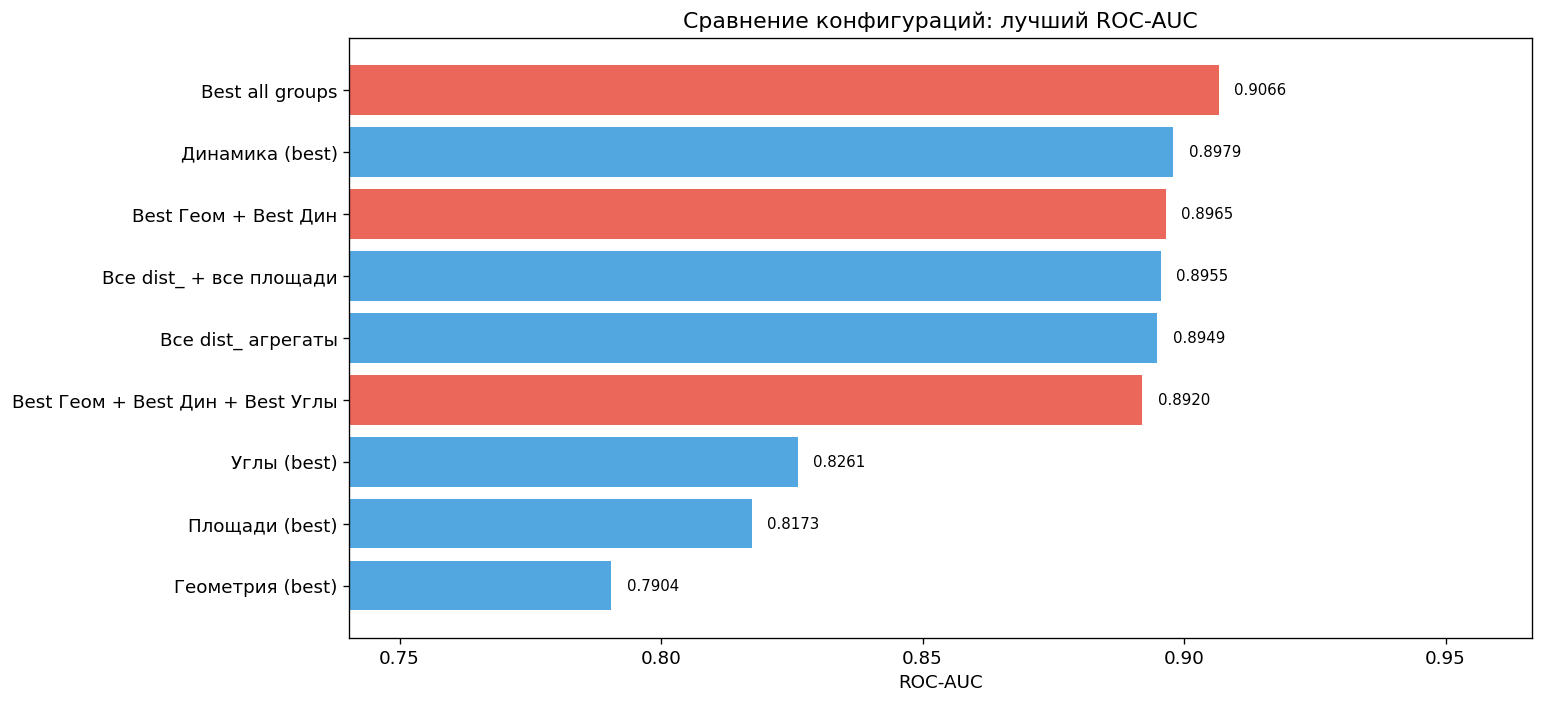

In [38]:
cross_rows = []
for lbl, res in cross_results.items():
    best_m = max(res, key=lambda m: res[m]['roc_auc'])
    cross_rows.append({'Конфигурация': lbl, 'Лучшая модель': best_m,
                       'ROC-AUC': round(res[best_m]['roc_auc'], 4),
                       'Bal.Acc': round(res[best_m]['bal_acc'], 4),
                       'Sens':    round(res[best_m]['sens'], 4),
                       'Spec':    round(res[best_m]['spec'], 4)})
cross_df = pd.DataFrame(cross_rows).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
display(cross_df.style.format({'ROC-AUC':'{:.4f}','Bal.Acc':'{:.4f}','Sens':'{:.4f}','Spec':'{:.4f}'}))

fig, ax = plt.subplots(figsize=(13, 6))
colors_bar = ['#e74c3c' if 'Best' in lbl else '#3498db' for lbl in cross_df['Конфигурация']]
ax.barh(cross_df['Конфигурация'][::-1], cross_df['ROC-AUC'][::-1],
        color=colors_bar[::-1], alpha=0.85)
ax.set_xlabel('ROC-AUC')
ax.set_title('Сравнение конфигураций: лучший ROC-AUC')
xleft = max(0.4, cross_df['ROC-AUC'].min() - 0.05)
ax.set_xlim(xleft, min(1.0, cross_df['ROC-AUC'].max() + 0.06))
for i, (lbl, val) in enumerate(zip(cross_df['Конфигурация'][::-1], cross_df['ROC-AUC'][::-1])):
    ax.text(val+0.003, i, f'{val:.4f}', va='center', fontsize=13)
plt.tight_layout(); plt.show()


## 10. Влияние клинического параметра `exercise_duration`

`exercise_duration` — длительность выполнения упражнения (число кадров). Брадикинезия при ПД
проявляется в увеличении времени выполнения моторного акта.


In [40]:
dur_col = [DURATION_COL] if DURATION_COL in df.columns else []

dur_configs_dist = {
    'Геометрия':     GEOM_AGGS,
    'Динамика':      DYN_AGGS,
    'Углы':          ANG_AGGS,
    'Геом+Дин':      GEOM_AGGS + DYN_AGGS,
    'Геом+Дин+Углы': ALL_DIST_AGGS,
}

dur_rows = []
for lbl, agg_list in dur_configs_dist.items():
    res_no_d, _ = run_models(agg_list, include_duration=False)
    res_ex_d, _ = run_models(agg_list, include_duration=True)
    best_no = max(res_no_d, key=lambda m: res_no_d[m]['roc_auc'])
    best_ex = max(res_ex_d, key=lambda m: res_ex_d[m]['roc_auc'])
    auc_no = res_no_d[best_no]['roc_auc']
    auc_ex = res_ex_d[best_ex]['roc_auc']
    dur_rows.append({'Конфигурация': lbl,
                     'AUC без ex_dur': f'{auc_no:.3f} ({best_no})',
                     'AUC с ex_dur':   f'{auc_ex:.3f} ({best_ex})',
                     'Delta AUC':      f'{auc_ex - auc_no:+.3f}'})
    print(f'{lbl}: AUC без={auc_no:.3f}, с={auc_ex:.3f}, delta={auc_ex-auc_no:+.3f}')
display(pd.DataFrame(dur_rows).set_index('Конфигурация'))


Геометрия: AUC без=0.778, с=0.795, delta=+0.017
Динамика: AUC без=0.898, с=0.905, delta=+0.007
Углы: AUC без=0.824, с=0.843, delta=+0.019
Геом+Дин: AUC без=0.905, с=0.909, delta=+0.004
Геом+Дин+Углы: AUC без=0.895, с=0.893, delta=-0.002


,AUC без ex_dur,AUC с ex_dur,Delta AUC
Конфигурация,,,
Геометрия,0.778 (LGBM),0.795 (LGBM),+0.017
Динамика,0.898 (XGB),0.905 (XGB),+0.007
Углы,0.824 (RF),0.843 (RF),+0.019
Геом+Дин,0.905 (XGB),0.909 (XGB),+0.004
Геом+Дин+Углы,0.895 (XGB),0.893 (XGB),-0.002


## 11. Сводка Block 2 и ROC-кривые лучшей конфигурации

In [42]:
colors_m = {'LR':'#3498db','RF':'#2ecc71','XGB':'#e74c3c','LGBM':'#f39c12','SVM':'#9b59b6'}

# Определяем лучшую конфигурацию из Block 2
summary_bl2 = []
for lbl, res in cross_results.items():
    best_m = max(res, key=lambda m: res[m]['roc_auc'])
    summary_bl2.append({'Конфигурация': lbl, 'Лучшая модель': best_m,
                        'ROC-AUC': round(res[best_m]['roc_auc'], 4),
                        'Bal.Acc': round(res[best_m]['bal_acc'], 4),
                        'Sens': round(res[best_m]['sens'], 4),
                        'Spec': round(res[best_m]['spec'], 4)})
df_summary_bl2 = pd.DataFrame(summary_bl2).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
display(df_summary_bl2.style.format({'ROC-AUC':'{:.4f}','Bal.Acc':'{:.4f}','Sens':'{:.4f}','Spec':'{:.4f}'}))

bl2_best_label = df_summary_bl2.iloc[0]['Конфигурация']
print(f'Лучшая конфигурация Block 2: {bl2_best_label}  (ROC-AUC = {df_summary_bl2.iloc[0]["ROC-AUC"]:.4f})')


,Конфигурация,Лучшая модель,ROC-AUC,Bal.Acc,Sens,Spec
0,Best all groups,LGBM,0.9066,0.7807,0.8475,0.7139
1,Динамика (best),XGB,0.8979,0.7701,0.8350,0.7052
2,Best Геом + Best Дин,XGB,0.8965,0.8135,0.8219,0.8051
3,Все dist_ + все площади,LGBM,0.8955,0.7613,0.8422,0.6804
4,Все dist_ агрегаты,XGB,0.8949,0.8235,0.8283,0.8186
5,Best Геом + Best Дин + Best Углы,XGB,0.8920,0.7995,0.8350,0.7641
6,Углы (best),RF,0.8261,0.6585,0.8733,0.4437
7,Площади (best),RF,0.8173,0.7070,0.8810,0.5331
8,Геометрия (best),LGBM,0.7904,0.6844,0.7493,0.6195


Лучшая конфигурация Block 2: Best all groups  (ROC-AUC = 0.9066)


X_best: (257, 759)


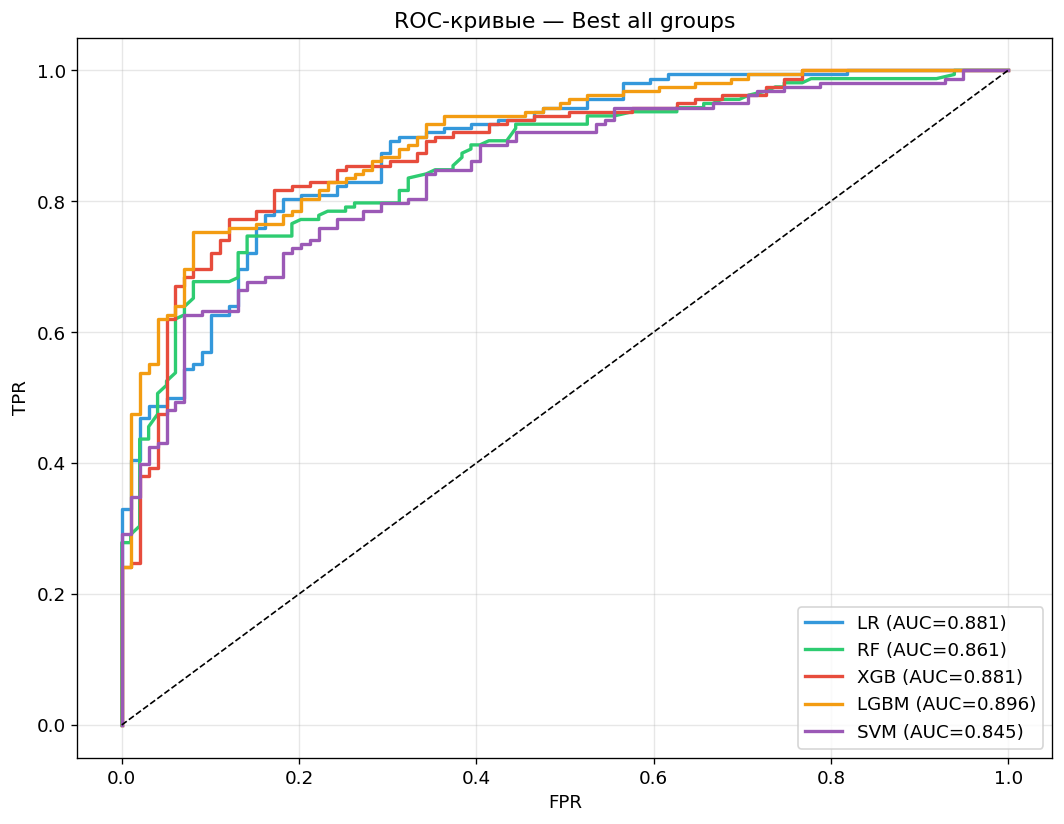

In [43]:
# Определяем X_best, y_best, groups_best для Block 3
_label_to_dist_agg = {
    'Геометрия (best)':              geom_best_list,
    'Динамика (best)':               dyn_best_list,
    'Углы (best)':                   ang_best_list,
    'Best Геом + Best Дин':          best_geom_dyn,
    'Best Геом + Best Дин + Best Углы': best_geom_dyn_ang,
    'Все dist_ агрегаты':            ALL_DIST_AGGS,
}

if bl2_best_label == 'Площади (best)':
    X_best, y_best, groups_best = prepare_area_data(area_best_list)
    _is_area_best = True
elif bl2_best_label == 'Best all groups':
    X_best, y_best, groups_best = X_best_all, y_best_all, g_best_all
    _is_area_best = False
elif bl2_best_label == 'Все dist_ + все площади':
    X_best, y_best, groups_best = X_all_full, y_all_full, g_all_full
    _is_area_best = False
else:
    agg_list_best = _label_to_dist_agg.get(bl2_best_label, ALL_DIST_AGGS)
    X_best, y_best, groups_best = prepare_data(agg_list_best)
    _is_area_best = False

best_res_bl2 = cross_results[bl2_best_label]
print(f'X_best: {X_best.shape}')

# ROC-кривые всех моделей
cv_roc = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
fig, ax = plt.subplots(figsize=(9, 7))
for mn in model_names:
    model = _make_models(y_best.values)[mn]
    oof_pr = np.zeros(len(y_best))
    for tr, te in cv_roc.split(X_best, y_best, groups_best):
        pipe = Pipeline([('corr', CorrelationFilter()), ('scaler', StandardScaler()),
                         ('model', clone(model))])
        pipe.fit(X_best.iloc[tr], y_best.iloc[tr])
        oof_pr[te] = pipe.predict_proba(X_best.iloc[te])[:,1]
    fpr, tpr, _ = roc_curve(y_best, oof_pr)
    auc_v = roc_auc_score(y_best, oof_pr)
    ax.plot(fpr, tpr, color=colors_m[mn], lw=2, label=f'{mn} (AUC={auc_v:.3f})')
ax.plot([0,1],[0,1],'k--',lw=1)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title(f'ROC-кривые — {bl2_best_label}')
ax.legend(loc='lower right'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


---

# Block 3. Детальный анализ лучшей конфигурации

Все эксперименты выполняются на конфигурации, определённой автоматически по Block 2.


## 12. Детальная оценка лучшей конфигурации

Конфигурация: Best all groups
X_best: (257, 759)
PD=158, Healthy=99
              precision    recall  f1-score   support

     Healthy       0.75      0.72      0.73        99
          PD       0.83      0.85      0.84       158

    accuracy                           0.80       257
   macro avg       0.79      0.78      0.78       257
weighted avg       0.80      0.80      0.80       257



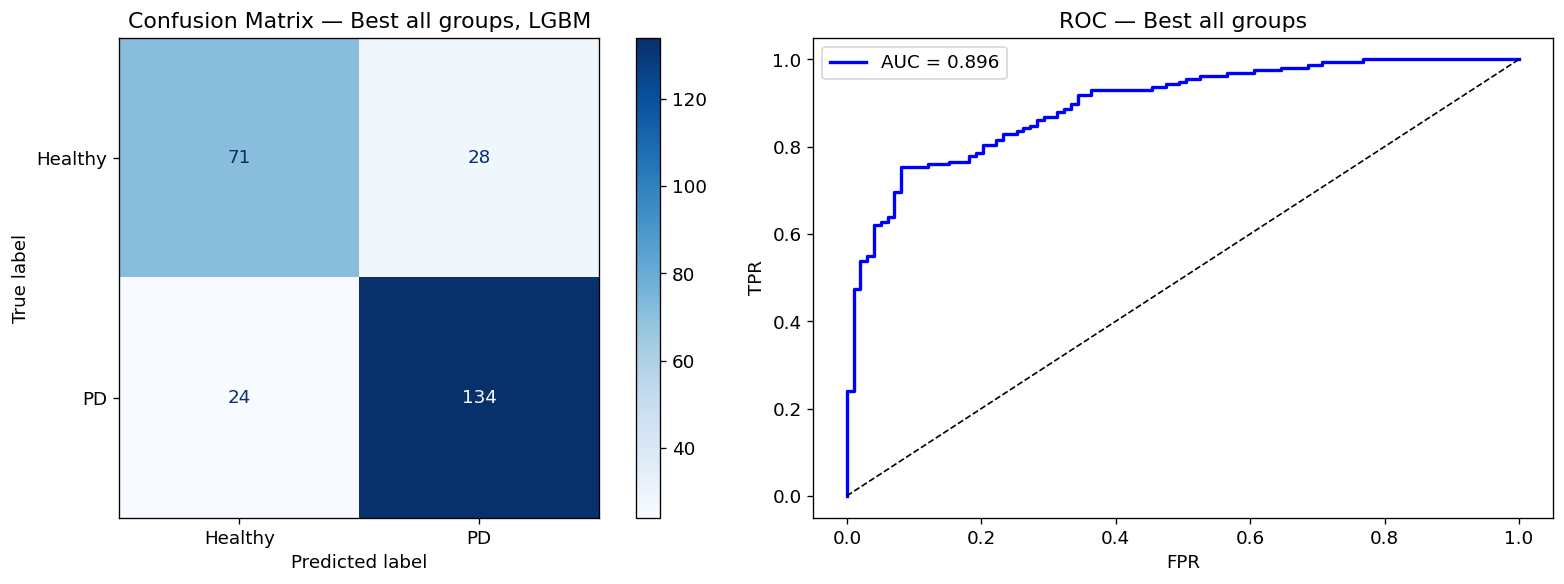

In [46]:
print(f'Конфигурация: {bl2_best_label}')
print(f'X_best: {X_best.shape}')
print(f'PD={y_best.sum()}, Healthy={(y_best==0).sum()}')

best_model_name_bl3 = max(model_names, key=lambda m: best_res_bl2[m]['roc_auc'])
best_model_bl3 = _make_models(y_best.values)[best_model_name_bl3]
cv_det = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

oof_preds_bl3 = np.zeros(len(y_best))
oof_proba_bl3 = np.zeros(len(y_best))
for tr, te in cv_det.split(X_best, y_best, groups_best):
    pipe = Pipeline([('corr', CorrelationFilter(0.95)),
                     ('scaler', StandardScaler()),
                     ('model', clone(best_model_bl3))])
    pipe.fit(X_best.iloc[tr], y_best.iloc[tr])
    oof_preds_bl3[te] = pipe.predict(X_best.iloc[te])
    oof_proba_bl3[te] = pipe.predict_proba(X_best.iloc[te])[:, 1]

print(classification_report(y_best, oof_preds_bl3, target_names=['Healthy','PD']))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm = confusion_matrix(y_best, oof_preds_bl3)
ConfusionMatrixDisplay(cm, display_labels=['Healthy','PD']).plot(
    ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title(f'Confusion Matrix — {bl2_best_label}, {best_model_name_bl3}')
fpr_b3, tpr_b3, _ = roc_curve(y_best, oof_proba_bl3)
auc_b3 = roc_auc_score(y_best, oof_proba_bl3)
axes[1].plot(fpr_b3, tpr_b3, 'b-', lw=2, label=f'AUC = {auc_b3:.3f}')
axes[1].plot([0,1],[0,1],'k--', lw=1)
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title(f'ROC — {bl2_best_label}'); axes[1].legend()
plt.tight_layout(); plt.show()


## 13. ROC-кривые всех моделей

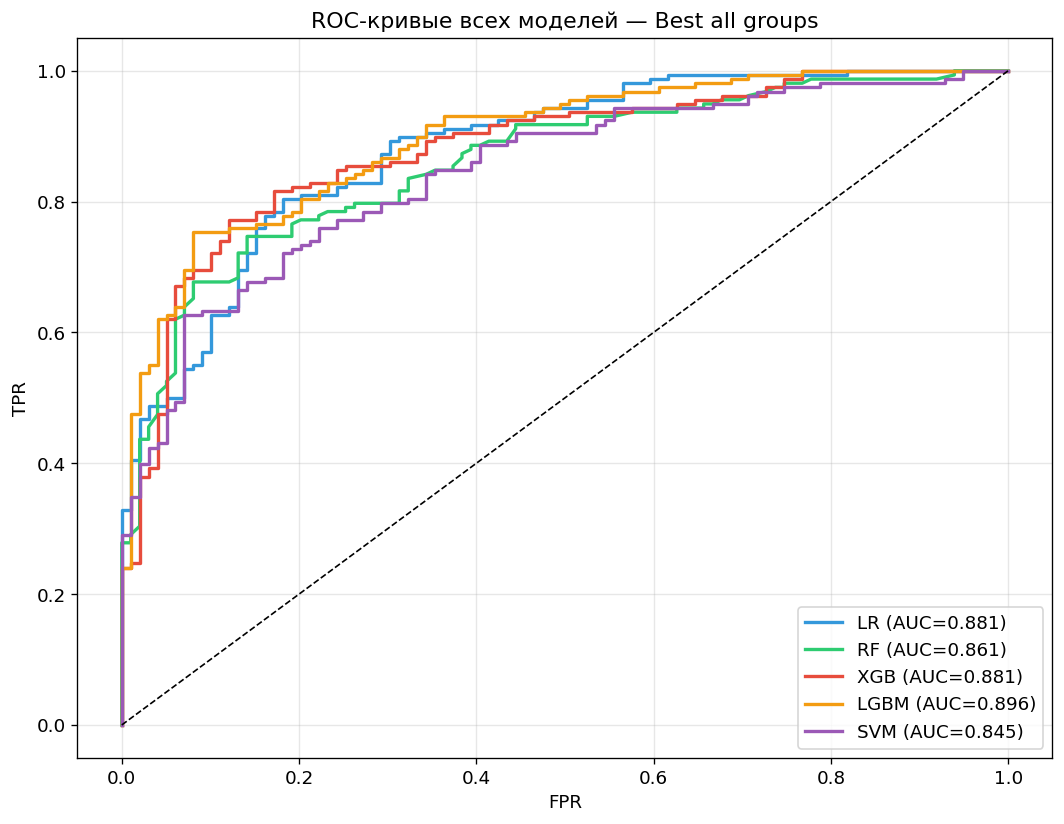

In [48]:
fig, ax = plt.subplots(figsize=(9, 7))
for mn in model_names:
    model = _make_models(y_best.values)[mn]
    oof_pr = np.zeros(len(y_best))
    for tr, te in cv_roc.split(X_best, y_best, groups_best):
        pipe = Pipeline([('corr', CorrelationFilter(0.95)), ('scaler', StandardScaler()),
                         ('model', clone(model))])
        pipe.fit(X_best.iloc[tr], y_best.iloc[tr])
        oof_pr[te] = pipe.predict_proba(X_best.iloc[te])[:,1]
    fpr, tpr, _ = roc_curve(y_best, oof_pr)
    ax.plot(fpr, tpr, color=colors_m[mn], lw=2,
            label=f'{mn} (AUC={roc_auc_score(y_best, oof_pr):.3f})')
ax.plot([0,1],[0,1],'k--',lw=1)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title(f'ROC-кривые всех моделей — {bl2_best_label}')
ax.legend(loc='lower right'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 14. Feature importance

Признаков после фильтра: 298


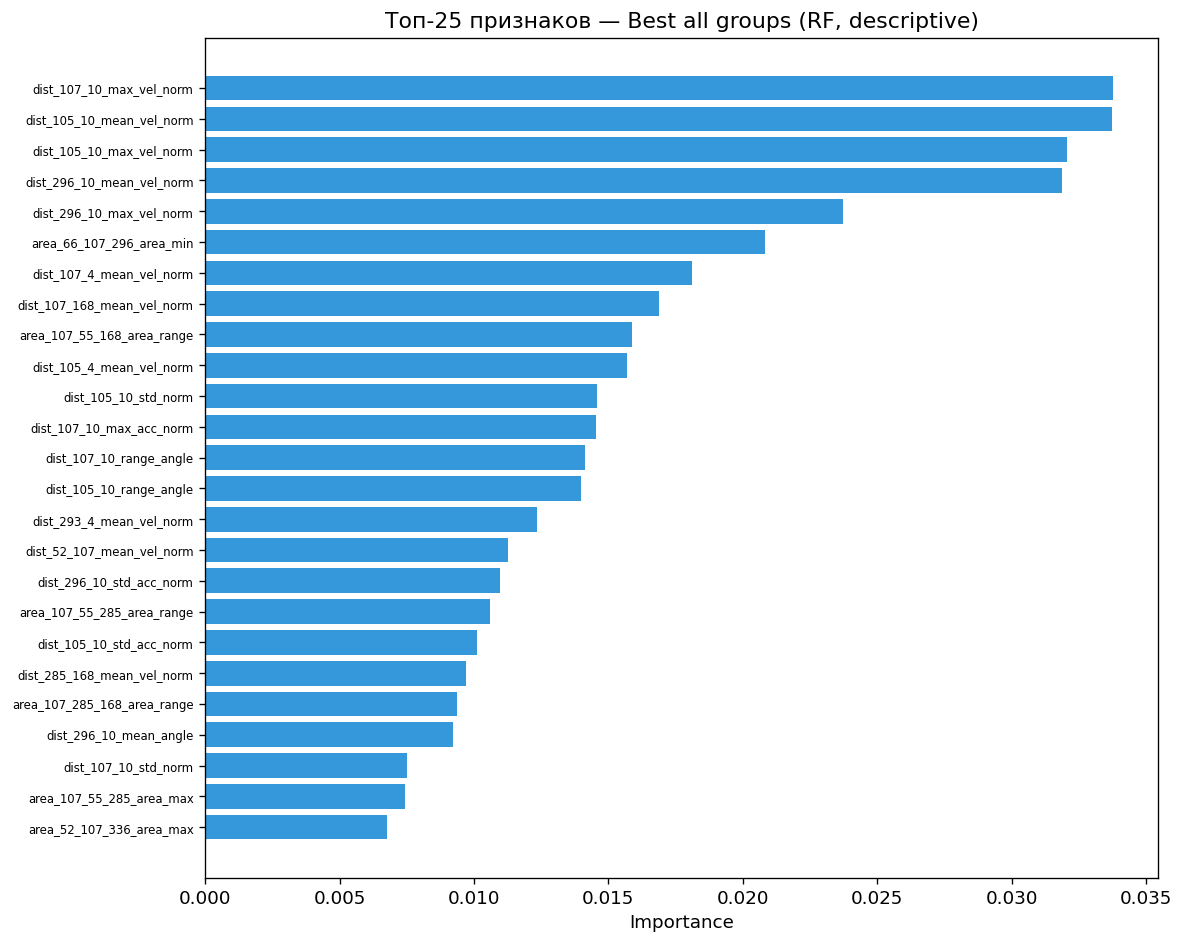

,feature,importance
0,dist_107_10_max_vel_norm,0.033766
1,dist_105_10_mean_vel_norm,0.033724
2,dist_105_10_max_vel_norm,0.032068
3,dist_296_10_mean_vel_norm,0.031862
4,dist_296_10_max_vel_norm,0.023742
5,area_66_107_296_area_min,0.020818
6,dist_107_4_mean_vel_norm,0.018108
7,dist_107_168_mean_vel_norm,0.016874
8,area_107_55_168_area_range,0.015879
9,dist_105_4_mean_vel_norm,0.015692


In [50]:
cf_fi = CorrelationFilter(0.95).fit(X_best)
X_best_f = X_best.iloc[:, np.where(cf_fi.keep_mask_)[0]]
filtered_names = X_best_f.columns.tolist()
print(f'Признаков после фильтра: {len(filtered_names)}')

rf_imp = RandomForestClassifier(n_estimators=500, class_weight='balanced',
                                 random_state=RANDOM_STATE, n_jobs=-1)
rf_imp.fit(StandardScaler().fit_transform(X_best_f), y_best)

imp = pd.DataFrame({'feature': filtered_names, 'importance': rf_imp.feature_importances_})
imp = imp.sort_values('importance', ascending=False).head(25)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(range(len(imp)), imp['importance'].values, color='#3498db')
ax.set_yticks(range(len(imp))); ax.set_yticklabels(imp['feature'].values, fontsize=13)
ax.set_xlabel('Importance')
ax.set_title(f'Топ-25 признаков — {bl2_best_label} (RF, descriptive)')
ax.invert_yaxis(); plt.tight_layout(); plt.show()
display(imp.reset_index(drop=True))


## 15. UMAP — визуализация и препроцессинг

### 15.1 2D-визуализация


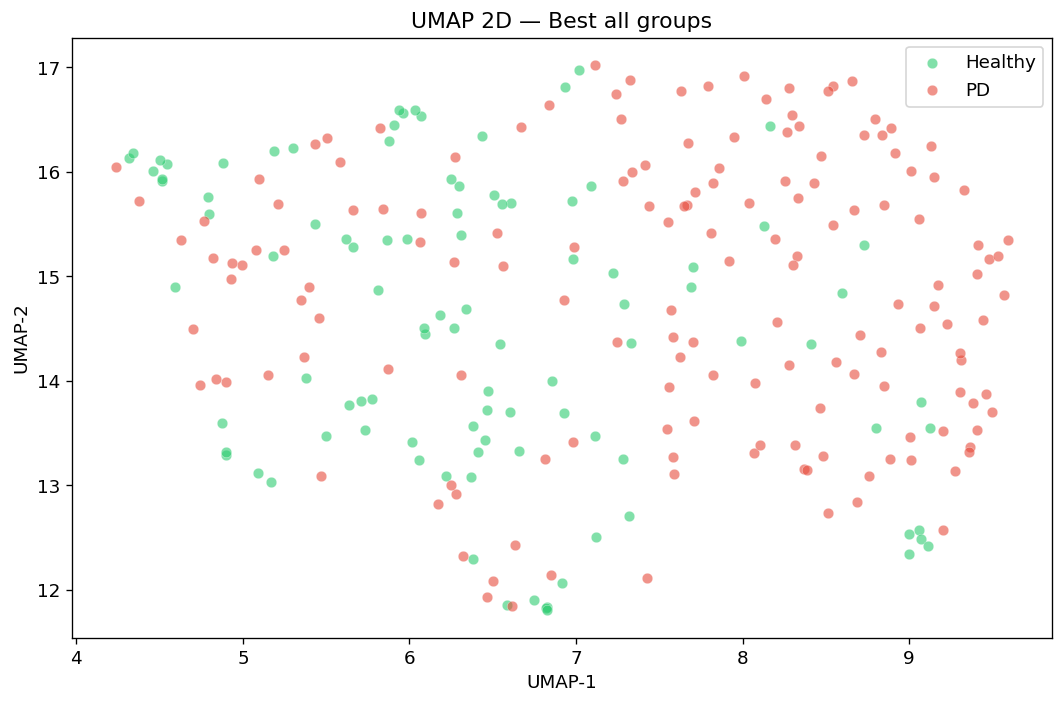

In [52]:
X_sc_umap = StandardScaler().fit_transform(X_best_f)
X_2d = UMAP(n_components=2, random_state=RANDOM_STATE, n_neighbors=15).fit_transform(X_sc_umap)

fig, ax = plt.subplots(figsize=(9, 6))
for lv, ln, lc in [(0,'Healthy','#2ecc71'),(1,'PD','#e74c3c')]:
    mask = y_best.values == lv
    ax.scatter(X_2d[mask,0], X_2d[mask,1], c=lc, label=ln, alpha=0.6, s=40,
               edgecolors='white', linewidth=0.3)
ax.set_title(f'UMAP 2D — {bl2_best_label}')
ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2'); ax.legend()
plt.tight_layout(); plt.show()


### 15.2 UMAP как препроцессинг

>>> UMAP n_components=5
>>> UMAP n_components=10
>>> UMAP n_components=20


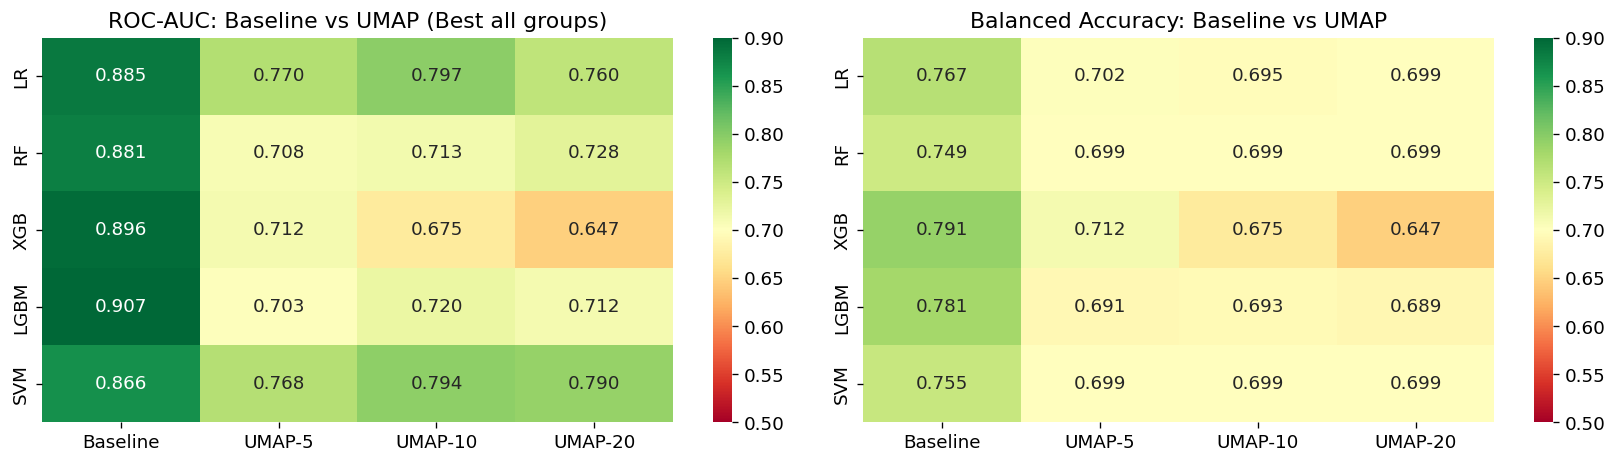

Лучший UMAP: n_components=10, AUC=0.797


In [54]:
n_components_list = [5, 10, 20]

def run_with_umap(X, y, groups, n_components):
    cv_u = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    res_u = {}
    for name, model in _make_models(y.values).items():
        pipe_u = Pipeline([
            ('corr',   CorrelationFilter(0.95)),
            ('scaler', StandardScaler()),
            ('umap',   UMAP(n_components=n_components, random_state=RANDOM_STATE, n_neighbors=15)),
            ('model',  model),
        ])
        cvr = cross_validate(pipe_u, X, y, groups=groups, cv=cv_u,
                             scoring=scoring, return_train_score=False)
        res_u[name] = {k: (np.mean(cvr[f'test_{k}']), np.std(cvr[f'test_{k}'])) for k in scoring}
    return res_u

umap_results = {}
for nc in n_components_list:
    print(f'>>> UMAP n_components={nc}')
    umap_results[nc] = run_with_umap(X_best, y_best, groups_best, nc)

col_labels = ['Baseline'] + [f'UMAP-{nc}' for nc in n_components_list]
hm_auc_u = np.zeros((len(model_names), len(col_labels)))
hm_bac_u = np.zeros((len(model_names), len(col_labels)))
for i, mn in enumerate(model_names):
    hm_auc_u[i, 0] = best_res_bl2[mn]['roc_auc']
    hm_bac_u[i, 0] = best_res_bl2[mn]['bal_acc']
    for j, nc in enumerate(n_components_list):
        hm_auc_u[i, j+1] = umap_results[nc][mn]['roc_auc'][0]
        hm_bac_u[i, j+1] = umap_results[nc][mn]['balanced_accuracy'][0]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.heatmap(hm_auc_u, xticklabels=col_labels, yticklabels=model_names,
            annot=True, fmt='.3f', cmap='RdYlGn', vmin=0.5, vmax=0.9, ax=axes[0])
axes[0].set_title(f'ROC-AUC: Baseline vs UMAP ({bl2_best_label})')
sns.heatmap(hm_bac_u, xticklabels=col_labels, yticklabels=model_names,
            annot=True, fmt='.3f', cmap='RdYlGn', vmin=0.5, vmax=0.9, ax=axes[1])
axes[1].set_title(f'Balanced Accuracy: Baseline vs UMAP')
plt.tight_layout(); plt.show()

best_nc = max(n_components_list,
              key=lambda nc: max(umap_results[nc][m]['roc_auc'][0] for m in model_names))
best_umap_auc = max(umap_results[best_nc][m]['roc_auc'][0] for m in model_names)
print(f'Лучший UMAP: n_components={best_nc}, AUC={best_umap_auc:.3f}')


## 16. SMOTE — балансировка классов

>>> SMOTE k=3
>>> SMOTE k=5


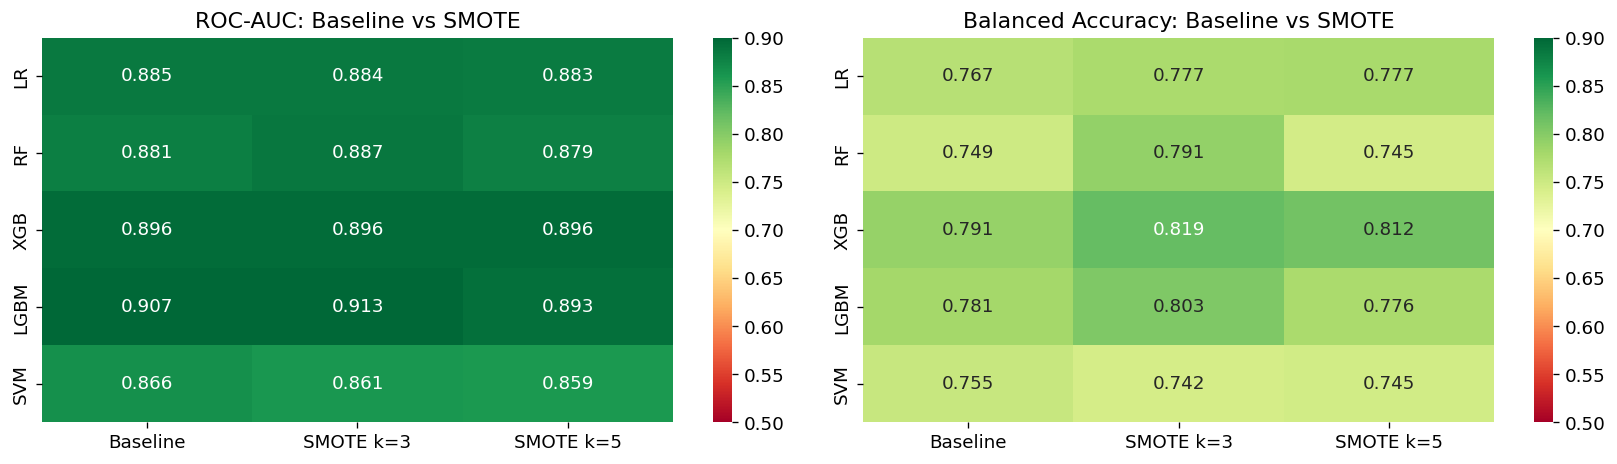

Лучший SMOTE AUC: 0.913


In [56]:
def run_with_smote(X, y, groups, k_neighbors=5):
    cv_s = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    res_s = {}
    for name, model in _make_models(y.values).items():
        pipe_s = ImbPipeline([
            ('corr',   CorrelationFilter(0.95)),
            ('scaler', StandardScaler()),
            ('smote',  SMOTE(random_state=RANDOM_STATE, k_neighbors=k_neighbors)),
            ('model',  model),
        ])
        cvr = cross_validate(pipe_s, X, y, groups=groups, cv=cv_s,
                             scoring=scoring, return_train_score=False)
        res_s[name] = {k: (np.mean(cvr[f'test_{k}']), np.std(cvr[f'test_{k}'])) for k in scoring}
    return res_s

smote_results = {}
for k in [3, 5]:
    print(f'>>> SMOTE k={k}')
    smote_results[k] = run_with_smote(X_best, y_best, groups_best, k)

cols_smote = ['Baseline', 'SMOTE k=3', 'SMOTE k=5']
hm_s_auc = np.zeros((len(model_names), 3))
hm_s_bac = np.zeros((len(model_names), 3))
for i, mn in enumerate(model_names):
    hm_s_auc[i,0] = best_res_bl2[mn]['roc_auc']
    hm_s_auc[i,1] = smote_results[3][mn]['roc_auc'][0]
    hm_s_auc[i,2] = smote_results[5][mn]['roc_auc'][0]
    hm_s_bac[i,0] = best_res_bl2[mn]['bal_acc']
    hm_s_bac[i,1] = smote_results[3][mn]['balanced_accuracy'][0]
    hm_s_bac[i,2] = smote_results[5][mn]['balanced_accuracy'][0]
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.heatmap(hm_s_auc, xticklabels=cols_smote, yticklabels=model_names,
            annot=True, fmt='.3f', cmap='RdYlGn', vmin=0.5, vmax=0.9, ax=axes[0])
axes[0].set_title(f'ROC-AUC: Baseline vs SMOTE')
sns.heatmap(hm_s_bac, xticklabels=cols_smote, yticklabels=model_names,
            annot=True, fmt='.3f', cmap='RdYlGn', vmin=0.5, vmax=0.9, ax=axes[1])
axes[1].set_title(f'Balanced Accuracy: Baseline vs SMOTE')
plt.tight_layout(); plt.show()

best_smote_auc = max(smote_results[k][m]['roc_auc'][0] for k in [3,5] for m in model_names)
print(f'Лучший SMOTE AUC: {best_smote_auc:.3f}')


## 17. Влияние `exercise_duration` на лучшую конфигурацию

In [58]:
if not _is_area_best:
    _agg_map = {
        'Геометрия (best)': geom_best_list, 'Динамика (best)': dyn_best_list,
        'Углы (best)': ang_best_list, 'Best Геом + Best Дин': best_geom_dyn,
        'Best Геом + Best Дин + Best Углы': best_geom_dyn_ang,
        'Все dist_ агрегаты': ALL_DIST_AGGS,
    }
    bl3_aggs = _agg_map.get(bl2_best_label, ALL_DIST_AGGS)
    X_no_dur, y_no_dur, g_no_dur = prepare_data(bl3_aggs, include_duration=False)
    X_wi_dur, y_wi_dur, g_wi_dur = prepare_data(bl3_aggs, include_duration=True)
    res_no_d, _ = run_models_xy(X_no_dur, y_no_dur, g_no_dur)
    res_wi_d, _ = run_models_xy(X_wi_dur, y_wi_dur, g_wi_dur)
    bm0 = max(res_no_d, key=lambda m: res_no_d[m]['roc_auc'])
    bm1 = max(res_wi_d, key=lambda m: res_wi_d[m]['roc_auc'])
    print(f'{bl2_best_label}:')
    print(f'  Без ex_dur:  AUC={res_no_d[bm0]["roc_auc"]:.3f} ({bm0})')
    print(f'  С ex_dur:    AUC={res_wi_d[bm1]["roc_auc"]:.3f} ({bm1})')
    print(f'  ΔAUC: {res_wi_d[bm1]["roc_auc"] - res_no_d[bm0]["roc_auc"]:+.3f}')
else:
    print('Лучшая конфигурация — площадные признаки; exercise_duration в wide-датасете.')


Best all groups:
  Без ex_dur:  AUC=0.895 (XGB)
  С ex_dur:    AUC=0.893 (XGB)
  ΔAUC: -0.002


## 18. Отбор признаков по направлению движения

`DirectionalFeatureSelector` оставляет min/max агрегаты только для пар с соответствующим направлением движения.
Сравниваются: Baseline / Directional (ε=0.02) / Minimal.


In [60]:
class DirectionalFeatureSelector(BaseEstimator, TransformerMixin):
    def __init__(self, eps=0.02, mode='directional'):
        self.eps = eps; self.mode = mode
    def fit(self, X, y=None):
        assert isinstance(X, pd.DataFrame)
        self.feature_names_in_ = list(X.columns)
        if self.mode == 'none':
            self.keep_columns_ = list(X.columns); return self
        mean_cols = [c for c in X.columns if c.startswith('dist_') and c.endswith('_mean_norm')]
        pair_means = {c.replace('_mean_norm', ''): X[c].mean() for c in mean_cols}
        keep = []
        for col in X.columns:
            if not col.startswith('dist_'):
                keep.append(col); continue
            if col.endswith('_max_norm'):
                if self.mode == 'minimal': continue
                pair = col.replace('_max_norm', '')
                if pair_means.get(pair, 1.0) > 1 + self.eps: keep.append(col)
            elif col.endswith('_min_norm'):
                if self.mode == 'minimal': continue
                pair = col.replace('_min_norm', '')
                if pair_means.get(pair, 1.0) < 1 - self.eps: keep.append(col)
            else:
                keep.append(col)
        self.keep_columns_ = keep; return self
    def transform(self, X):
        if isinstance(X, pd.DataFrame): return X[self.keep_columns_]
        idx = [self.feature_names_in_.index(c) for c in self.keep_columns_]
        return X[:, idx]


def run_config_dir(X, y, groups, directional_kwargs):
    cv_d = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    models_d = _make_models(y.values); res = {}
    n_feats_dir = None
    for name, model in models_d.items():
        pipe = Pipeline([
            ('direct', DirectionalFeatureSelector(**directional_kwargs)),
            ('corr',   CorrelationFilter(threshold=0.95)),
            ('scaler', StandardScaler()),
            ('model',  model),
        ])
        cvr = cross_validate(pipe, X, y, groups=groups, cv=cv_d,
                             scoring=scoring, return_train_score=False,
                             return_estimator=(name == 'LR'))
        if name == 'LR':
            n_feats_dir = len(cvr['estimator'][0].named_steps['direct'].keep_columns_)
        res[name] = {k: (np.mean(cvr[f'test_{k}']), np.std(cvr[f'test_{k}'])) for k in scoring}
    res['_n_direct'] = n_feats_dir
    return res

print('Baseline...'); res_baseline = run_config_dir(X_best, y_best, groups_best, {'mode':'none'})
print('Directional e=0.02...'); res_directional = run_config_dir(X_best, y_best, groups_best, {'eps':0.02,'mode':'directional'})
print('Minimal...'); res_minimal = run_config_dir(X_best, y_best, groups_best, {'mode':'minimal'})
print('Готово.')
print(f"  Baseline признаков: {res_baseline['_n_direct']}")
print(f"  Directional признаков: {res_directional['_n_direct']}")
print(f"  Minimal признаков: {res_minimal['_n_direct']}")


Baseline...
Directional e=0.02...
Minimal...
Готово.
  Baseline признаков: 759
  Directional признаков: 711
  Minimal признаков: 711


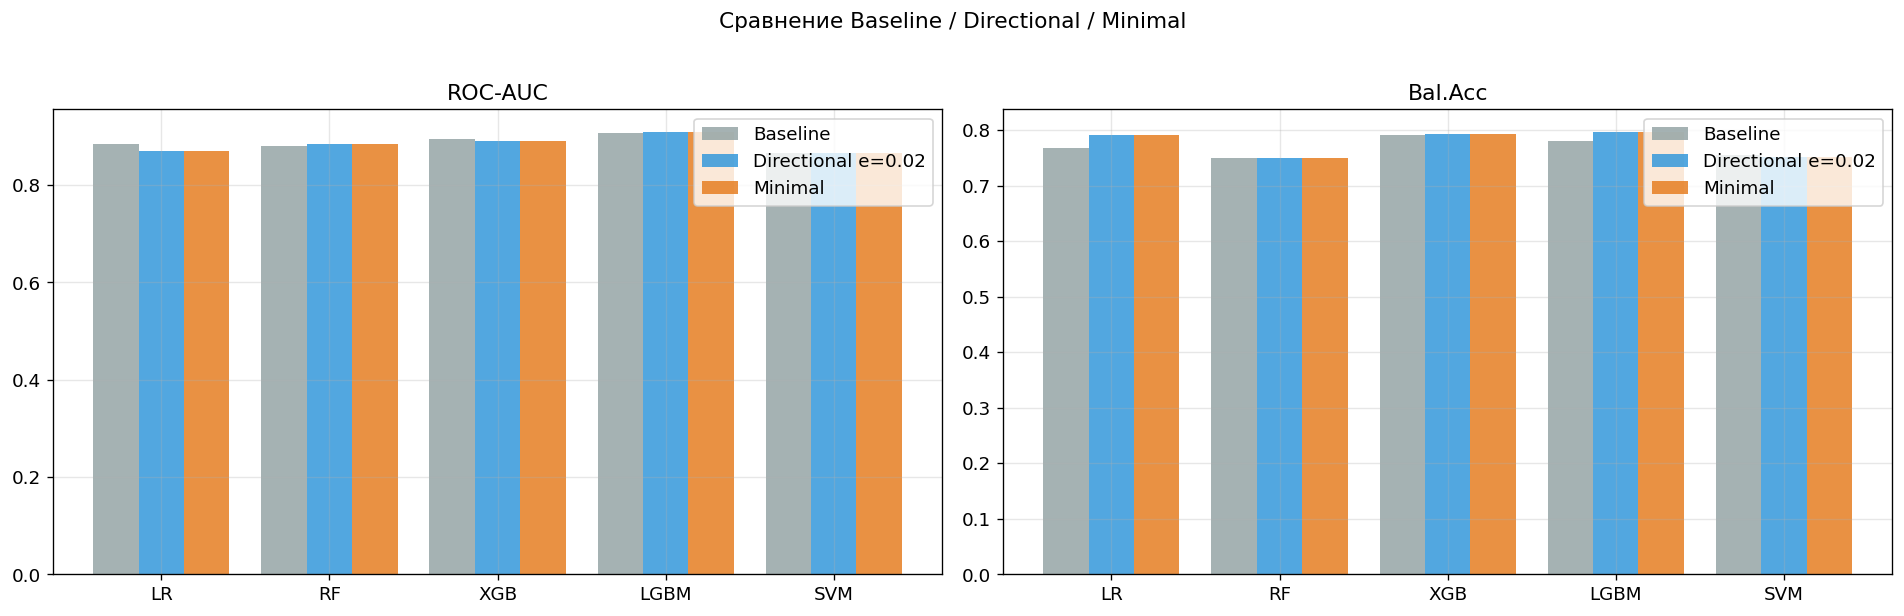

In [61]:
x = np.arange(len(model_names)); w = 0.27
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Сравнение Baseline / Directional / Minimal', fontsize=13, y=1.02)
for ax_i, (metric, label) in enumerate([('roc_auc','ROC-AUC'),('balanced_accuracy','Bal.Acc')]):
    vb = [res_baseline[m][metric][0] for m in model_names]
    vd = [res_directional[m][metric][0] for m in model_names]
    vm = [res_minimal[m][metric][0] for m in model_names]
    axes[ax_i].bar(x-w, vb, w, label='Baseline',          color='#95a5a6', alpha=0.85)
    axes[ax_i].bar(x,   vd, w, label='Directional e=0.02', color='#3498db', alpha=0.85)
    axes[ax_i].bar(x+w, vm, w, label='Minimal',           color='#e67e22', alpha=0.85)
    axes[ax_i].set_xticks(x); axes[ax_i].set_xticklabels(model_names)
    axes[ax_i].set_title(label); axes[ax_i].legend(); axes[ax_i].grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 19. Стандартные методы отбора признаков sklearn

Сравниваются: SelectKBest(f_classif), SelectFromModel(L1-LogReg), RFE(LogReg, n=20).


In [63]:
def run_with_selector(selector, X=None, y_=None, groups_=None):
    if X is None: X, y_, groups_ = X_best, y_best, groups_best
    cv_sel = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    models_sel = _make_models(y_.values); res = {}
    for name, model in models_sel.items():
        pipe = Pipeline([
            ('corr',   CorrelationFilter(threshold=0.95)),
            ('scaler', StandardScaler()),
            ('select', clone(selector) if selector is not None else 'passthrough'),
            ('model',  clone(model)),
        ])
        cvr = cross_validate(pipe, X, y_, groups=groups_, cv=cv_sel,
                             scoring=scoring, return_train_score=False)
        res[name] = {k: (np.mean(cvr[f'test_{k}']), np.std(cvr[f'test_{k}'])) for k in scoring}
    return res

selector_results = {'Baseline (без отбора)': {m: {k: (best_res_bl2[m]['roc_auc'] if k=='roc_auc' else
                                                       best_res_bl2[m]['bal_acc'] if k=='balanced_accuracy' else
                                                       best_res_bl2[m]['sens'] if k=='sensitivity' else
                                                       best_res_bl2[m]['spec'] if k=='specificity' else
                                                       best_res_bl2[m]['f1'] if k=='f1' else 0, 0)
                                                   for k in scoring}
                                               for m in model_names}}
for k in [10, 20, 50]:
    print(f'>>> SelectKBest k={k}')
    selector_results[f'SelectKBest k={k}'] = run_with_selector(SelectKBest(f_classif, k=k))
print('>>> SelectFromModel (L1)')
l1_est = LogisticRegression(penalty='l1', solver='saga', C=0.1, max_iter=2000,
                             class_weight='balanced', random_state=RANDOM_STATE)
selector_results['SelectFromModel L1'] = run_with_selector(SelectFromModel(l1_est))
print('>>> RFE n=20')
rfe_est = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE)
selector_results['RFE n=20'] = run_with_selector(RFE(rfe_est, n_features_to_select=20, step=10))
print('Готово.')

>>> SelectKBest k=10
>>> SelectKBest k=20
>>> SelectKBest k=50
>>> SelectFromModel (L1)
>>> RFE n=20
Готово.


,Configuration,Best Model,ROC-AUC,Bal.Acc,Sens,Spec
0,Baseline (без отбора),LGBM,0.907,0.781,0.848,0.714
1,SelectKBest k=10,LR,0.875,0.798,0.816,0.779
2,SelectKBest k=20,LR,0.887,0.802,0.854,0.750
3,SelectKBest k=50,XGB,0.908,0.825,0.867,0.783
4,SelectFromModel L1,LGBM,0.876,0.741,0.835,0.648
5,RFE n=20,XGB,0.883,0.797,0.842,0.752


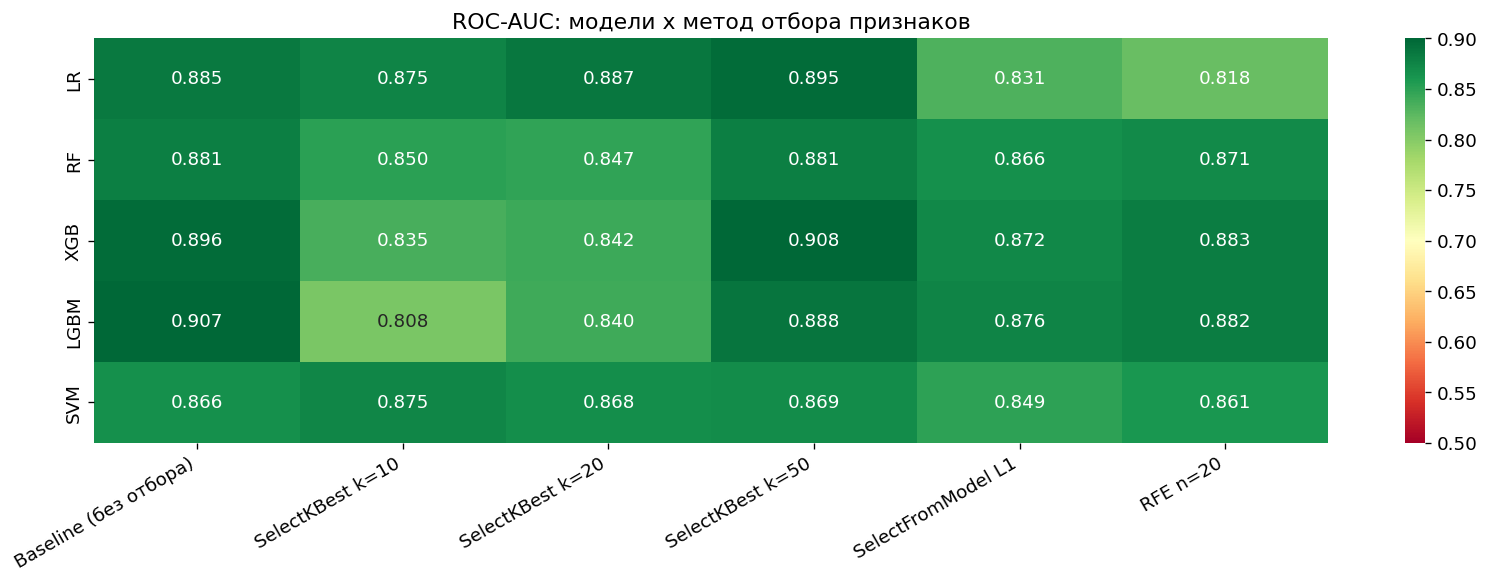

In [64]:
rows = []
for conf_name, res in selector_results.items():
    bm = max(res, key=lambda m: res[m]['roc_auc'][0])
    r  = res[bm]
    rows.append({'Configuration': conf_name, 'Best Model': bm,
                 'ROC-AUC': f'{r["roc_auc"][0]:.3f}',
                 'Bal.Acc': f'{r["balanced_accuracy"][0]:.3f}',
                 'Sens':    f'{r["sensitivity"][0]:.3f}',
                 'Spec':    f'{r["specificity"][0]:.3f}'})
display(pd.DataFrame(rows))

conf_names = list(selector_results.keys())
hm_sel = np.zeros((len(model_names), len(conf_names)))
for i, mn in enumerate(model_names):
    for j, cn in enumerate(conf_names):
        hm_sel[i,j] = selector_results[cn][mn]['roc_auc'][0]
fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(hm_sel, xticklabels=conf_names, yticklabels=model_names,
            annot=True, fmt='.3f', cmap='RdYlGn', vmin=0.5, vmax=0.9, ax=ax)
ax.set_title('ROC-AUC: модели x метод отбора признаков')
plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()


## 20. Nested Cross-Validation

Несмещённая оценка с одновременным подбором гиперпараметров.
- Внешний цикл: `StratifiedGroupKFold(5)` — пациент не попадает в train/test одновременно.
- Внутренний цикл: `GridSearchCV` с `StratifiedKFold(3)`.


In [66]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

param_grids = {
    'LR':   {'model__C': [0.01, 0.1, 1, 10]},
    'RF':   {'model__n_estimators': [100, 300], 'model__max_depth': [None, 5, 10]},
    'XGB':  {'model__learning_rate': [0.05, 0.1, 0.2],
              'model__max_depth': [3, 5], 'model__n_estimators': [100, 200]},
    'LGBM': {'model__learning_rate': [0.05, 0.1],
              'model__num_leaves': [31, 63], 'model__n_estimators': [100, 200]},
    'SVM':  {'model__C': [0.1, 1, 10]},
}

outer_cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

nested_results = {}
for mn, model in _make_models(y_best.values).items():
    pipe = Pipeline([
        ('corr',   CorrelationFilter(threshold=0.95)),
        ('scaler', StandardScaler()),
        ('model',  clone(model)),
    ])
    gs = GridSearchCV(pipe, param_grids[mn], cv=inner_cv,
                      scoring='roc_auc', n_jobs=-1, refit=True)
    outer_aucs = []
    for tr_idx, te_idx in outer_cv.split(X_best, y_best, groups_best):
        X_tr, y_tr = X_best.iloc[tr_idx], y_best.iloc[tr_idx]
        X_te, y_te = X_best.iloc[te_idx], y_best.iloc[te_idx]
        gs.fit(X_tr, y_tr)
        prob = gs.best_estimator_.predict_proba(X_te)[:, 1]
        outer_aucs.append(roc_auc_score(y_te, prob))
    nested_results[mn] = {'aucs': outer_aucs, 'mean': float(np.mean(outer_aucs)),
                          'std': float(np.std(outer_aucs))}
    print(f'{mn}: AUC = {np.mean(outer_aucs):.3f} +/- {np.std(outer_aucs):.3f}')


LR: AUC = 0.881 +/- 0.052
RF: AUC = 0.881 +/- 0.047
XGB: AUC = 0.891 +/- 0.034
LGBM: AUC = 0.907 +/- 0.037
SVM: AUC = 0.860 +/- 0.034


,Model,Nested CV AUC,Baseline AUC,DELTA
0,LR,0.881+/-0.052,0.885,-0.004
1,RF,0.881+/-0.047,0.881,-0.000
2,XGB,0.891+/-0.034,0.896,-0.005
3,LGBM,0.907+/-0.037,0.907,+0.000
4,SVM,0.860+/-0.034,0.866,-0.006


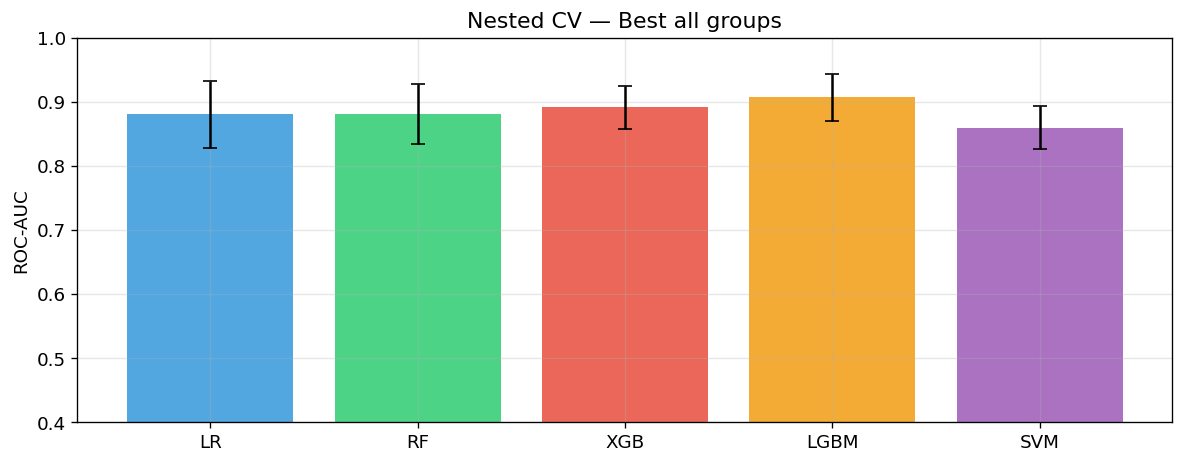

In [67]:
nest_rows = []
for mn in model_names:
    r = nested_results[mn]
    nest_rows.append({'Model': mn, 'Nested CV AUC': f'{r["mean"]:.3f}+/-{r["std"]:.3f}',
                      'Baseline AUC': f'{best_res_bl2[mn]["roc_auc"]:.3f}',
                      'DELTA': f'{r["mean"] - best_res_bl2[mn]["roc_auc"]:+.3f}'})
display(pd.DataFrame(nest_rows))

fig, ax = plt.subplots(figsize=(10, 4))
means = [nested_results[m]['mean'] for m in model_names]
stds  = [nested_results[m]['std']  for m in model_names]
ax.bar(model_names, means, yerr=stds, capsize=4,
       color=[colors_m[m] for m in model_names], alpha=0.85)
ax.set_ylabel('ROC-AUC'); ax.set_title(f'Nested CV — {bl2_best_label}')
ax.set_ylim(0.4, 1.0); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 21. Валидация на retake r0

Оценка на строго независимом подмножестве: только первые попытки каждого пациента (r0).
Модель обучается на всех данных, тестируется на r0-записях.


In [69]:
df_r0      = df[df['r'] == 'r0'].copy()
df_wide_r0 = df_wide[df_wide['r'] == 'r0'].copy()
n_pd_r0  = df_r0[df_r0.label == 1]['Patient'].nunique()
n_hc_r0  = df_r0[df_r0.label == 0]['Patient'].nunique()
print(f'r0: {df_r0["Patient"].nunique()} пациентов ({n_pd_r0} PD / {n_hc_r0} Healthy)')
print(f'Наблюдений: {len(df_r0)} строк')
print(f'Конфигурация Block 2: {bl2_best_label}')
print()

# Строим X_r0_only в зависимости от типа лучшей конфигурации
if bl2_best_label == 'Площади (best)':
    feat_area_r0 = get_area_feat(area_best_list)
    X_r0_only  = df_wide_r0[feat_area_r0]
    y_r0_only  = df_wide_r0['label']
    g_r0_only  = df_wide_r0['id'].rename('Patient')

elif bl2_best_label in ('Best all groups', 'Все dist_ + все площади'):
    # Для сборных конфигураций берём X_best и фильтруем по r0 индексам
    r0_mask = groups_best.isin(df_r0['Patient'].unique())
    X_r0_only = X_best[r0_mask]
    y_r0_only = y_best[r0_mask]
    g_r0_only = groups_best[r0_mask]

elif bl2_best_label in _label_to_dist_agg:
    agg_list_r0 = _label_to_dist_agg[bl2_best_label]
    if len(agg_list_r0) == 1:
        sub_r0     = df[(df['Aggregate'] == agg_list_r0[0]) & (df['r'] == 'r0')]
        X_r0_only  = sub_r0[[c for c in dist_cols]]
        y_r0_only  = sub_r0['label']
        g_r0_only  = sub_r0['Patient']
    else:
        sub_r0 = df[(df['Aggregate'].isin(agg_list_r0)) & (df['r'] == 'r0')]
        pivot_r0 = sub_r0.pivot_table(index=['Patient','r','label'],
                                       columns='Aggregate', values=dist_cols)
        pivot_r0.columns = [f'{f}_{a}' for f, a in pivot_r0.columns]
        pivot_r0 = pivot_r0.reset_index()
        feat_r0    = [c for c in pivot_r0.columns if c.startswith('dist_')]
        X_r0_only  = pivot_r0[feat_r0]
        y_r0_only  = pivot_r0['label']
        g_r0_only  = pivot_r0['Patient']
else:
    print('Неизвестная конфигурация — пропускаем r0')
    X_r0_only = None

if X_r0_only is not None:
    print(f'X_r0_only: {X_r0_only.shape}  PD={y_r0_only.sum()}  Healthy={(y_r0_only==0).sum()}')
    print()

    # Честная CV на r0-подмножестве (не обучаем на всём датасете)
    res_r0_cv, _ = run_models_xy(X_r0_only, y_r0_only, g_r0_only)

    r0_rows = []
    for mn in model_names:
        full_auc = best_res_bl2[mn]['roc_auc']
        r0_auc   = res_r0_cv[mn]['roc_auc']
        r0_rows.append({
            'Модель':            mn,
            'AUC (все retake)':  round(full_auc, 3),
            'AUC (r0 only)':     round(r0_auc,   3),
            'Δ':                 round(r0_auc - full_auc, 3),
            'Bal.Acc (r0)':      round(res_r0_cv[mn]['bal_acc'], 3),
        })

    r0_df = pd.DataFrame(r0_rows).set_index('Модель')
    display(r0_df.style.set_caption(f'Устойчивость к r0 — {bl2_best_label}'))

    best_r0_mn   = max(res_r0_cv,  key=lambda m: res_r0_cv[m]['roc_auc'])
    best_full_mn = max(best_res_bl2, key=lambda m: best_res_bl2[m]['roc_auc'])
    auc_r0_val   = res_r0_cv[best_r0_mn]['roc_auc']
    auc_full_val = best_res_bl2[best_full_mn]['roc_auc']
    diff = auc_r0_val - auc_full_val

    print(f'Лучший AUC (все retake): {auc_full_val:.3f} ({best_full_mn})')
    print(f'Лучший AUC (r0 only):    {auc_r0_val:.3f} ({best_r0_mn})')
    print(f'Δ = {diff:+.3f}')
    if abs(diff) < 0.05:
        print('Вывод: стабильно — retake-confound отсутствует.')
    else:
        print('Внимание: значительное расхождение — retake может быть confounding-фактором.')

r0: 150 пациентов (124 PD / 26 Healthy)
Наблюдений: 1950 строк
Конфигурация Block 2: Best all groups

X_r0_only: (252, 759)  PD=158  Healthy=94



,AUC (все retake),AUC (r0 only),Δ,Bal.Acc (r0)
Модель,,,,
LR,0.885000,0.814000,-0.071000,0.742000
RF,0.881000,0.862000,-0.019000,0.700000
XGB,0.896000,0.841000,-0.055000,0.786000
LGBM,0.907000,0.855000,-0.052000,0.750000
SVM,0.866000,0.801000,-0.066000,0.723000


Лучший AUC (все retake): 0.907 (LGBM)
Лучший AUC (r0 only):    0.862 (RF)
Δ = -0.045
Вывод: стабильно — retake-confound отсутствует.


## 22. Сводные результаты

,Конфигурация,Лучший AUC
0,16. SMOTE,0.913
1,18. Directional,0.910
2,9. Best all,0.907
3,20. Nested CV,0.907
4,6. Динамика,0.898
5,9. Best Геом+Дин,0.896
6,9. Все dist_+площади,0.895
7,7. Углы,0.826
8,8. Площади (best),0.817
9,15. UMAP-10,0.797


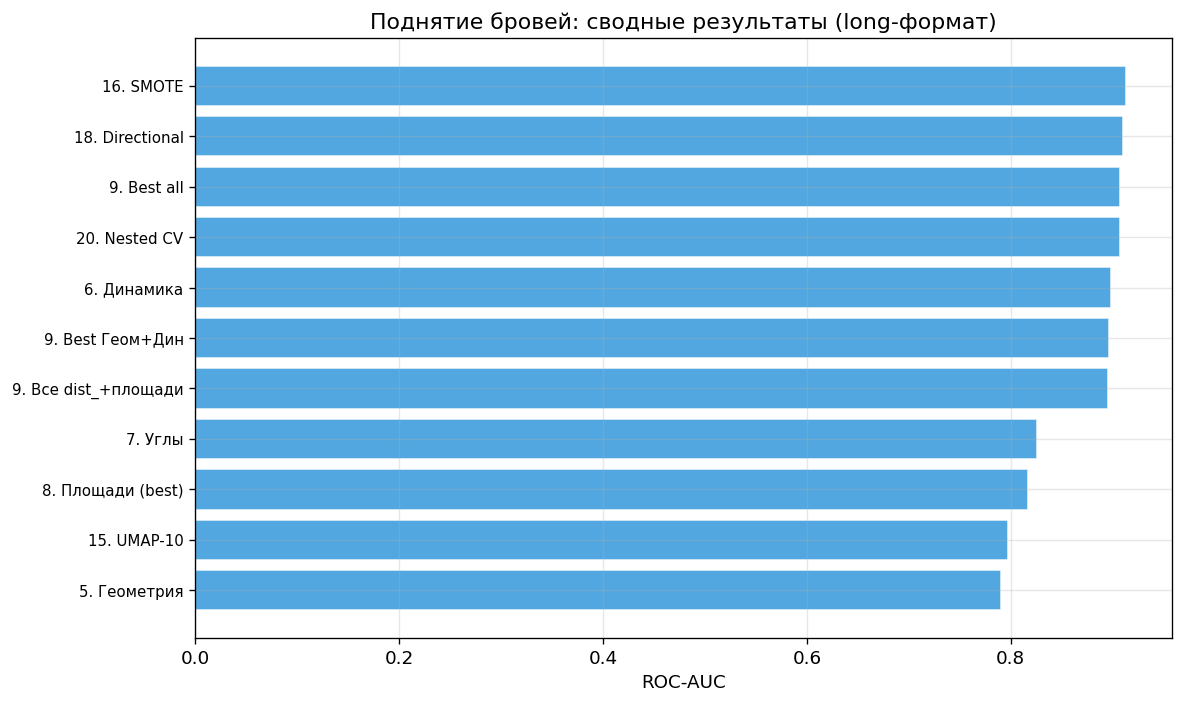

In [71]:
def best_auc_res(res):
    return max(res[m]['roc_auc'] for m in model_names)

summary_rows = [
    {'Конфигурация': '5. Геометрия',        'Лучший AUC': f'{best_auc_res(geom_combos[geom_best_name]["res"]):.3f}'},
    {'Конфигурация': '6. Динамика',         'Лучший AUC': f'{best_auc_res(dyn_combos[dyn_best_name]["res"]):.3f}'},
    {'Конфигурация': '7. Углы',             'Лучший AUC': f'{best_auc_res(ang_combos[ang_best_name]["res"]):.3f}'},
    {'Конфигурация': '8. Площади (best)',   'Лучший AUC': f'{best_auc_res(area_combos[area_best_name]["res"]):.3f}'},
    {'Конфигурация': '9. Best Геом+Дин',   'Лучший AUC': f'{best_auc_res(cross_results["Best Геом + Best Дин"]):.3f}'},
    {'Конфигурация': '9. Best all',         'Лучший AUC': f'{best_auc_res(cross_results["Best all groups"]):.3f}'},
    {'Конфигурация': '9. Все dist_+площади','Лучший AUC': f'{best_auc_res(cross_results["Все dist_ + все площади"]):.3f}'},
    {'Конфигурация': f'15. UMAP-{best_nc}', 'Лучший AUC': f'{best_umap_auc:.3f}'},
    {'Конфигурация': f'16. SMOTE',          'Лучший AUC': f'{best_smote_auc:.3f}'},
    {'Конфигурация': '18. Directional',     'Лучший AUC': f'{max(res_directional[m]["roc_auc"][0] for m in model_names):.3f}'},
    {'Конфигурация': '20. Nested CV',       'Лучший AUC': f'{max(nested_results[m]["mean"] for m in model_names):.3f}'},
]
sum_df = pd.DataFrame(summary_rows)
sum_df['_auc'] = sum_df['Лучший AUC'].astype(float)
sum_df = sum_df.sort_values('_auc', ascending=False).drop(columns=['_auc']).reset_index(drop=True)
display(sum_df)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(sum_df)), sum_df['Лучший AUC'].astype(float),
        color='#3498db', alpha=0.85, edgecolor='white')
ax.set_yticks(range(len(sum_df)))
ax.set_yticklabels(sum_df['Конфигурация'].values, fontsize=13)
ax.invert_yaxis()
ax.set_xlabel('ROC-AUC')
ax.set_title('Поднятие бровей: сводные результаты (long-формат)')
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
